# ESc1 signal EDA — training data only

All diagnostics below use the complete training portion, indexed by `msgStamp`. The final 20% of the labeled **elapsed time span** is reserved before any EDA. There is no row subsampling.

Earlier notebook versions inspected the full dataset. This split is excluded from this run and future model selection, but is not a retrospectively pristine holdout. Correlations and serial-correlation tests are descriptive, not evidence of out-of-sample predictability.

All diagnostics, full coverage, exception samples and date counts, package versions, and interpretation are kept in this notebook. Only the split boundaries are saved separately, in `splits.json` at the repository root.

In [1]:
from pathlib import Path
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
from scipy.cluster.hierarchy import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'takehome').exists())
sys.path.insert(0, str(ROOT / 'src'))
from takehome.data import column_coverage, training_data
from takehome.plots import heatmap
from takehome.eda import (
    acf_matrix, autocorrelation_table, bell_shape_table, correlation_clustering,
    correlation_to_column, infer_feature_cols, monthly_shift_scores, redundant_pairs,
)

DATA_PATH = Path(os.environ.get('DATA_PATH', ROOT / 'ESc1_signal_components_5min (6).parquet'))
SCATTER_N_FEATURES = 9  # Limit displayed columns, never observations.
ACF_LAG, SEASONAL_NLAGS = 15, 288

## 0. Load, set msgStamp index, reserve the test span

Let `first` and `last` be the first and last non-null `ret_5m` timestamps. The boundary is `first + 0.8 * (last - first)`. Training is `[first, boundary)` and the reserved test block is `[boundary, last]`. This is a time split, so row percentages need not equal 80/20. Outside-span unlabeled rows are excluded; internal missing observations are retained.

In [2]:
raw = pd.read_parquet(DATA_PATH)
if raw.index.name and raw.index.name not in raw.columns:
    raw = raw.reset_index()
raw = raw.set_index('msgStamp')
if not isinstance(raw.index, pd.DatetimeIndex):
    if pd.api.types.is_numeric_dtype(raw.index.dtype):
        raise ValueError('Numeric msgStamp: specify its epoch unit explicitly before converting.')
    raw.index = pd.to_datetime(raw.index, errors='raise')
raw = raw.sort_index()
df, split = training_data(raw)
del raw  # Do not retain a full-sample frame for later cells to accidentally use.

assert df.index.name == 'msgStamp'
assert len(df) == split['train_rows'] and df.index.max() < split['cutoff']
print(split.to_string())
print(f'Training timestamps: {df.index.min()} through {df.index.max()}')
(ROOT / 'splits.json').write_text(json.dumps(split.to_dict(), default=str, indent=2))
from takehome.features import with_cashflow_feature
df = with_cashflow_feature(df)  # x100: raw ratio; undefined ratios remain missing.
feature_cols = infer_feature_cols(df)
price_col, cashflow_col, time_col = 'adjMid', 'cashflow', 'msgStamp'
print(f'Training shape: {df.shape}; features: {len(feature_cols)}')
display(df.head())

first_label               2014-01-02 06:05:00-05:00
cutoff                    2022-07-14 00:33:00-04:00
last_label                2024-08-30 16:55:00-04:00
train_rows                                   640734
test_rows                                    160325
train_fraction_of_time                          0.8
Training timestamps: 2014-01-02 06:05:00-05:00 through 2022-07-14 00:30:00-04:00
Training shape: (640734, 106); features: 100


,trade_date,wmid,adjMid,volume,cashflow,ret_5m,x1,x2,x3,x4,...,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100
msgStamp,,,,,,,,,,,,,,,,,,,,,
2014-01-02 06:05:00-05:00,2014-01-02,1836.844118,2008.598998,17893.0,1836.0,-0.000680,-0.000189,-0.000143,-0.000093,0.000485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.102610
2014-01-02 06:10:00-05:00,2014-01-02,1835.672917,2007.232232,3809.0,-961.0,0.000409,-0.000308,-0.000268,-0.000200,-0.000034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.252297
2014-01-02 06:15:00-05:00,2014-01-02,1836.407635,2008.052291,3328.0,-187.0,0.000136,-0.001099,-0.000780,-0.000550,-0.000549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.056190
2014-01-02 06:20:00-05:00,2014-01-02,1836.811905,2008.325645,2498.0,300.0,0.000681,-0.001608,-0.001347,-0.001034,-0.000054,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120096
2014-01-02 06:25:00-05:00,2014-01-02,1838.159786,2009.692410,2528.0,-369.0,0.000952,-0.001579,-0.001705,-0.001486,0.000182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.145965


### Added predictor: x100

`x100 = cashflow / volume`, appended after x99 and included in all feature families and fits. This is the raw ratio, **not clipped** to [-1, 1]. Zero-volume and nonfinite ratios remain missing. Only the regression design later replaces missing predictors with zero; the EDA frame is not imputed. The feature is formed after the training/test split.

### Per-column coverage — training data only

First and last **non-null msgStamp** for every column, non-null count, and percentage of training rows that are null. Entirely missing columns remain visible with `NaT` bounds. No test-period distribution statistics are computed.

In [3]:
coverage = column_coverage(df)
with pd.option_context('display.max_rows', None):
    display(coverage)

,first_valid,last_valid,non_null,null_pct
column,,,,
trade_date,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,640734,0.000000
wmid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
adjMid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
volume,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
cashflow,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
ret_5m,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,590635,7.819001
x1,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x2,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x3,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793


## ES tradability: exchange schedule versus missing quotes

Estimate weekday/local-clock quote availability using **training wmid only**. Reindex onto a complete five-minute grid for this diagnostic so absent weekends count as absent, rather than disappearing from the denominator. This does not fill prices or alter the modeling frame.

The empirical gaps indicate the Sunday evening open, Friday evening close, daily maintenance and a historical afternoon pause. They also show boundary labels consistent with **end-labeled five-minute bars**: the first bar after 18:00 New York is 18:05. A closing-bar quote is not proof that a new trade can be entered after the close.

`is_tradable` is the **scheduled exchange-open instant** mask. `is_trading_bar` asks whether the entire trailing five-minute bar was within a scheduled open interval. `quote_available` is kept separate. Missing quotes are not automatically exchange closures, and the schedule alone does not capture outages, circuit breakers or contract-specific halts.

Schedule sources: [CME holiday calendar](https://www.cmegroup.com/trading-hours.html), [September 21, 2015 close change](https://www.cmegroup.com/tools-information/lookups/advisories/electronic-trading/20150817.html), [June 28, 2021 afternoon-pause removal](https://www.cmegroup.com/notices/electronic-trading/2021/06/20210621.html), and [December 5, 2018 abbreviated session](https://www.cmegroup.com/notices/clearing/2018/12/Chadv18-474.html). The implementation uses pinned `pandas_market_calendars` CME_Equity holiday rules with those dated corrections, not 2026 holiday dates projected backward. Remaining vendor/calendar discrepancies are shown rather than silently discarded; future holiday schedules should be checked against CME notices.

All times below are America/New_York. Before 2015-09-21, regular close was 17:15; thereafter 17:00. Before 2021-06-28, the 16:15–16:30 pause applied; thereafter it did not. Regular reopen is 18:00 Sunday through Thursday.

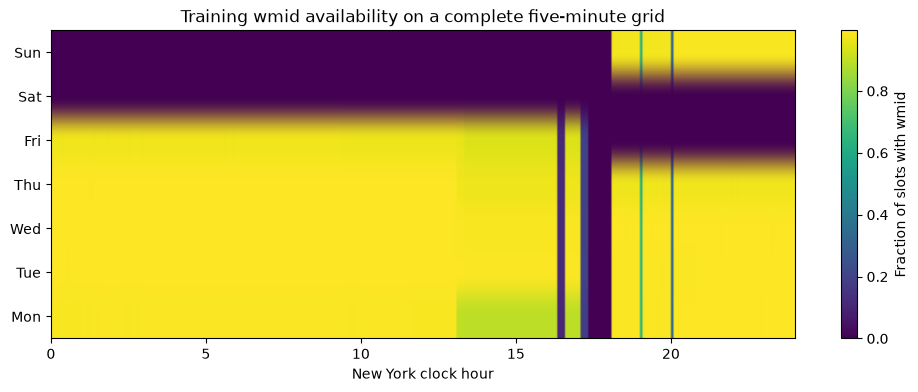

,Before close change,After close change,After pause removal
16:15,0.957528,0.956146,0.959731
16:20,0.000000,0.000000,0.959731
16:30,0.000000,0.000000,0.959731
16:35,0.957528,0.956146,0.959731
17:00,0.957528,0.956146,0.959731
17:05,0.957528,0.000000,0.000000
17:15,0.957528,0.000000,0.000000
17:20,0.000000,0.000000,0.000000
18:00,0.000000,0.000000,0.000000
18:05,0.788789,0.788704,0.792593


wmid_present,False,True
scheduled_trading_bar,,
False,40674,51
True,3107,596902


,session_diagnostics
training_rows,640734
scheduled_open_instants,600009
scheduled_trading_bars,600009
quotes_present,596953
missing_quotes_in_scheduled_bars,3107
quotes_outside_scheduled_bars,51


Dates with the most quotes outside the schedule (audit, not automatic relabeling):


,rows
2014-07-03,3
2014-11-28,3
2014-12-24,3
2015-11-27,3
2015-12-24,3
2016-11-25,3
2017-07-03,3
2017-11-24,3
2018-07-03,3
2018-11-23,3


SESSION_DIAGNOSTICS
training_rows                       640734
scheduled_open_instants             600009
scheduled_trading_bars              600009
quotes_present                      596953
missing_quotes_in_scheduled_bars      3107
quotes_outside_scheduled_bars           51
ERA_AVAILABILITY
       Before close change  After close change  After pause removal
16:15             0.957528            0.956146             0.959731
16:20             0.000000            0.000000             0.959731
16:30             0.000000            0.000000             0.959731
16:35             0.957528            0.956146             0.959731
17:00             0.957528            0.956146             0.959731
17:05             0.957528            0.000000             0.000000
17:15             0.957528            0.000000             0.000000
17:20             0.000000            0.000000             0.000000
18:00             0.000000            0.000000             0.000000
18:05             0.78878

In [4]:
from takehome.sessions import is_tradable as es_is_tradable, es_schedule, availability_by_week

weekly_availability = availability_by_week(df['wmid'])
weekly = weekly_availability['has_wmid'].unstack('weekday').reindex(columns=range(7))
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(weekly.T, aspect='auto', origin='lower', extent=(0, 24, -.5, 6.5))
ax.set_yticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.set_xlabel('New York clock hour'); ax.set_title('Training wmid availability on a complete five-minute grid')
fig.colorbar(im, ax=ax, label='Fraction of slots with wmid'); plt.show(); plt.close('all')

# A single pooled weekly rule would hide historical changes.
era_profiles = {}
for name, start, end in [('Before close change', '2014-01-01', '2015-09-20'),
                          ('After close change', '2015-09-21', '2021-06-27'),
                          ('After pause removal', '2021-06-28', '2022-07-14')]:
    q = df.loc[start:end, 'wmid']
    p = availability_by_week(q)
    era_profiles[name] = p.loc[p.index.get_level_values('weekday') < 5, 'has_wmid'].groupby('minute').mean()
boundaries = [16*60+15,16*60+20,16*60+30,16*60+35,17*60,17*60+5,17*60+15,17*60+20,18*60,18*60+5,19*60,20*60]
era_availability = pd.DataFrame(era_profiles).reindex(boundaries)
era_availability.index = [f'{m//60:02d}:{m%60:02d}' for m in boundaries]
display(era_availability)

is_tradable = es_is_tradable(df.index)
is_trading_bar = es_is_tradable(df.index, bar_end=True)
quote_available = df['wmid'].notna()
display(pd.crosstab(is_trading_bar.rename('scheduled_trading_bar'), quote_available.rename('wmid_present')))
session_diagnostics = pd.Series({
    'training_rows': len(df), 'scheduled_open_instants': int(is_tradable.sum()),
    'scheduled_trading_bars': int(is_trading_bar.sum()), 'quotes_present': int(quote_available.sum()),
    'missing_quotes_in_scheduled_bars': int((is_trading_bar & ~quote_available).sum()),
    'quotes_outside_scheduled_bars': int((~is_trading_bar & quote_available).sum()),
}, name='session_diagnostics')
display(session_diagnostics.to_frame())
calendar_mismatches = df.loc[~is_trading_bar & quote_available, ['wmid']]
print('Dates with the most quotes outside the schedule (audit, not automatic relabeling):')
display(calendar_mismatches.groupby(calendar_mismatches.index.date).size().nlargest(12).to_frame('rows'))
print('SESSION_DIAGNOSTICS'); print(session_diagnostics.to_string())
print('ERA_AVAILABILITY'); print(era_availability.to_string())

### Calendar audit and use

The recurring isolated missing slot around 19:00 winter / 20:00 summer New York corresponds to midnight UTC and looks like a data-production artifact, not a CME maintenance interval. Do not train an exchange calendar by treating every recurring NaN as a market closure.

The mask is defined for later fitting/execution workflows and can be generated without future prices. Existing standalone P&Ls and the ad hoc combination below are deliberately **not silently filtered** by this newly introduced mask, so their definitions remain comparable. To impose trading restrictions later, apply the schedule at the trade-decision/label interval, with explicit bar-label and fill conventions. The calendar is a scheduled-open model, not a guarantee of executable liquidity.

## 1. Scatter matrix

Nine representative feature columns are shown for readability, using **all their training observations**. Missing pairs are omitted by the plotting routine; rows are not sampled. The all-feature correlation matrix below covers all feature pairs.

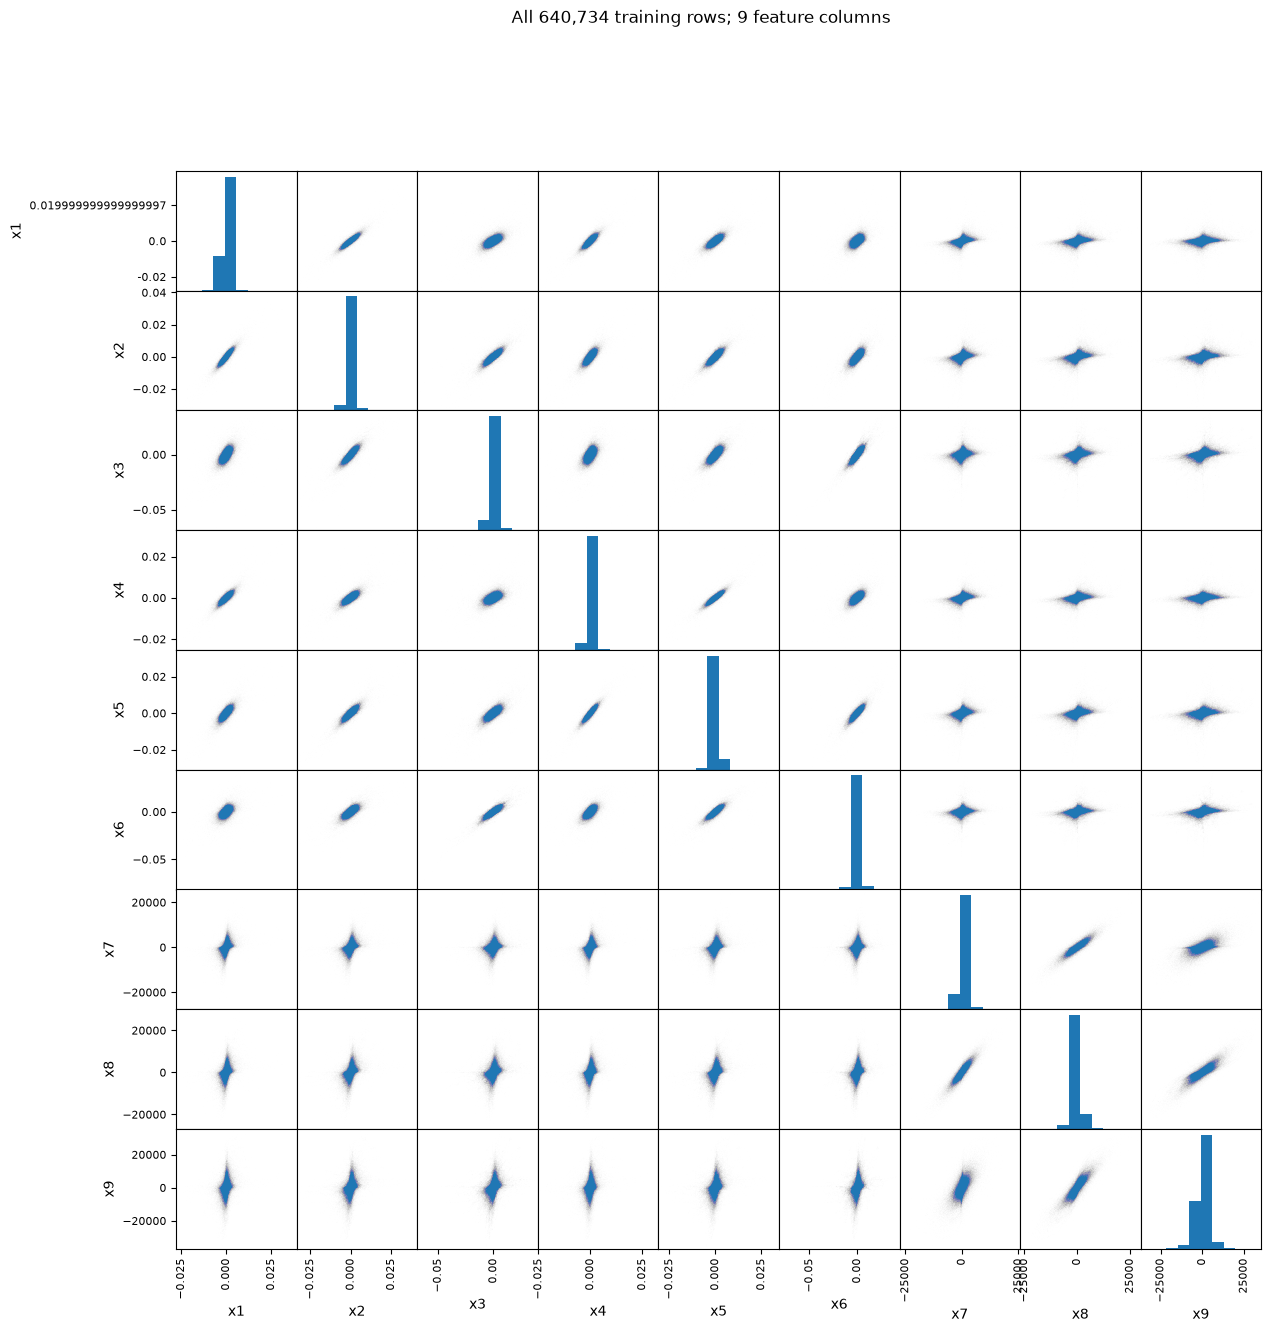

In [5]:
scatter_features = [c for c in feature_cols if df[c].nunique() > 1][:SCATTER_N_FEATURES]
scatter_matrix(df[scatter_features], figsize=(14, 14), diagonal='hist',
               alpha=.08, s=.2, rasterized=True)
plt.suptitle(f'All {len(df):,} training rows; {len(scatter_features)} feature columns', y=.995)
plt.show()
plt.close('all')

## 2. Distribution-shape screen and return sanity check

No Gaussianity test. The full-sample screen flags a dip statistic above 0.01, absolute Bowley quartile skew above 0.25, an exact point mass above 10%, or fewer than 20 unique values. These are practical degeneracy thresholds, not calibrated hypothesis tests; a pass does not prove a bell shape. High kurtosis is deliberately allowed.

Using the [Hartigan dip statistic](https://github.com/RUrlus/diptest) rather than its iid p-value avoids both a sample cap and interpreting tiny large-sample departures as useful rejections. Serially dependent features are not iid.

`adjMid.pct_change(fill_method=None)` is a contemporaneous sanity check. The supplied `ret_5m` is also reported separately; its alignment is not assumed to match that price change. All values and sample counts below are training-only.

,feature,n,nunique,max_mass,robust_skew,dip_stat,bell_like
6,x7,346261,345026,0.002940,0.065775,inf,False
68,x69,9126,9126,0.000110,-0.019220,0.002129,True
66,x67,9126,9126,0.000110,-0.012363,0.001646,True
67,x68,9126,9126,0.000110,-0.059021,0.001637,True
11,x12,16560,16560,0.000060,-0.036038,0.001600,True
...,...,...,...,...,...,...,...
56,x57,480744,480744,0.000002,-0.010753,0.000172,True
58,x59,338841,338841,0.000003,0.024714,0.000165,True
40,x41,446749,446749,0.000002,-0.029800,0.000164,True
54,x55,480744,480744,0.000002,0.037573,0.000145,True


Pass shape screen: 99/100; flagged: 1


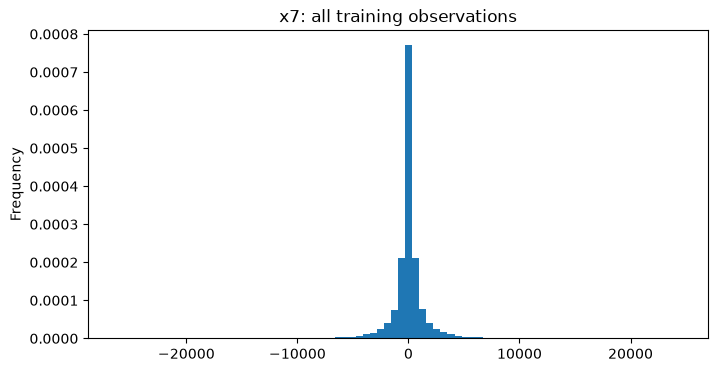

,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
60,x61,0.415557,0.000000e+00,0.350083,0.000000e+00,168937,0.000000e+00,0.000000e+00,0.415557
57,x58,-0.411100,0.000000e+00,-0.337529,0.000000e+00,338832,0.000000e+00,0.000000e+00,0.411100
42,x43,0.381231,0.000000e+00,0.313393,0.000000e+00,168935,0.000000e+00,0.000000e+00,0.381231
36,x37,0.351904,0.000000e+00,0.295867,0.000000e+00,168823,0.000000e+00,0.000000e+00,0.351904
45,x46,0.345192,0.000000e+00,0.282360,0.000000e+00,99355,0.000000e+00,0.000000e+00,0.345192
99,x100,0.077271,0.000000e+00,0.337293,0.000000e+00,584307,0.000000e+00,0.000000e+00,0.337293
33,x34,0.332063,0.000000e+00,0.264749,0.000000e+00,161112,0.000000e+00,0.000000e+00,0.332063
9,x10,0.286760,6.345562e-311,0.328594,0.000000e+00,16560,1.379470e-310,0.000000e+00,0.328594
66,x67,0.321950,4.098448e-219,0.314194,3.150248e-208,9126,7.881631e-219,6.429077e-208,0.321950
51,x52,0.319535,0.000000e+00,0.285254,0.000000e+00,167411,0.000000e+00,0.000000e+00,0.319535


Top correlations to supplied ret_5m (not assumed contemporaneous):


,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
57,x58,0.018288,1.831179e-26,0.025212,9.105777e-49,338777,1.831179e-24,9.105777e-47,0.025212
6,x7,-0.001722,3.108236e-01,-0.023301,8.598336e-43,346205,4.257858e-01,2.149584e-41,0.023301
9,x10,-0.007924,3.078746e-01,-0.021978,4.678876e-03,16560,4.257858e-01,8.507047e-03,0.021978
39,x40,-0.001265,3.978454e-01,-0.021057,5.449059e-45,446673,5.113141e-01,1.816353e-43,0.021057
33,x34,-0.020514,1.799257e-16,-0.016435,4.186711e-11,161114,5.997525e-15,2.462771e-10,0.020514
54,x55,-0.000528,7.141038e-01,-0.020364,2.843706e-45,480723,7.761998e-01,1.421853e-43,0.020364
12,x13,-0.003123,2.229217e-01,-0.019904,7.865186e-15,152348,3.483151e-01,7.048631e-14,0.019904
15,x16,-0.002247,3.805279e-01,-0.019792,1.111916e-14,152348,5.006947e-01,8.553199e-14,0.019792
60,x61,-0.018851,9.356760e-15,-0.018883,8.458357e-15,168885,1.871352e-13,7.048631e-14,0.018883
34,x35,-0.018762,5.022619e-14,-0.007524,2.527138e-03,161114,8.371031e-13,4.768185e-03,0.018762


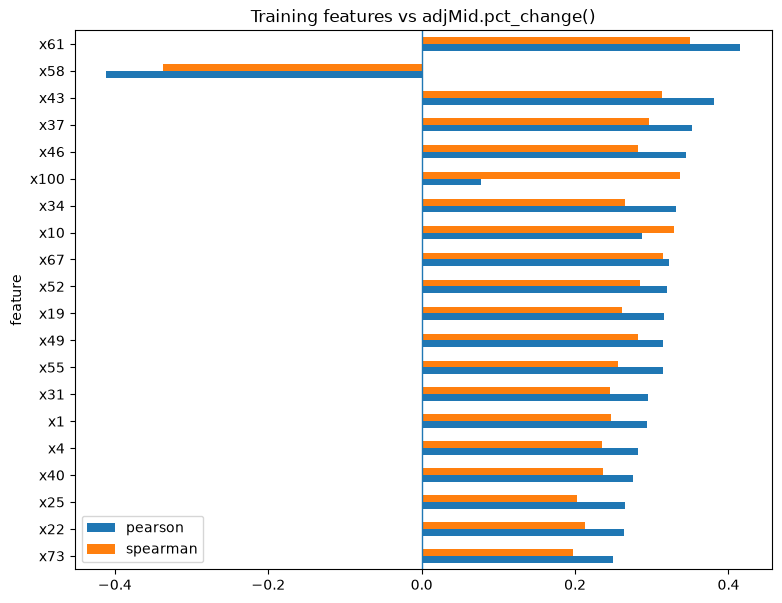

In [6]:
shape = bell_shape_table(df, feature_cols)
flagged_shape = shape.loc[~shape.bell_like]
display(shape)
print(f'Pass shape screen: {shape.bell_like.sum()}/{len(shape)}; flagged: {len(flagged_shape)}')
assert shape.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
for col in flagged_shape.feature.head(6):
    df[col].plot.hist(bins=80, density=True, figsize=(8, 4), title=f'{col}: all training observations')
    plt.show()
    plt.close('all')

df['_ret1'] = df.adjMid.pct_change(fill_method=None)
return_corr = correlation_to_column(df, '_ret1', feature_cols)
provided_corr = correlation_to_column(df, 'ret_5m', feature_cols)
strong_target = return_corr.loc[return_corr.max_abs_corr >= .10]
display(strong_target)
print('Top correlations to supplied ret_5m (not assumed contemporaneous):')
display(provided_corr.head(15))
return_corr.head(20).sort_values('max_abs_corr').plot.barh(
    x='feature', y=['pearson', 'spearman'], figsize=(9, 7),
    title='Training features vs adjMid.pct_change()')
plt.axvline(0, linewidth=1)
plt.show()
plt.close('all')

## 3. Feature correlation and dendrogram

Cluster using distance $1-|\rho_S|$ so strongly positive and strongly negative variants are grouped together. The heatmap retains signed Spearman correlation.

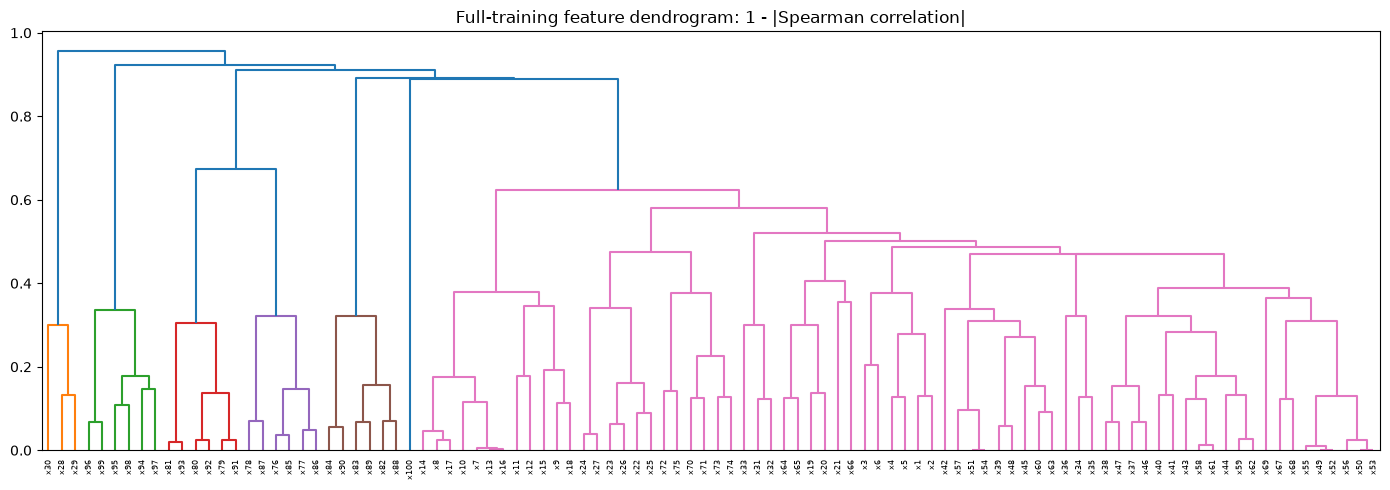

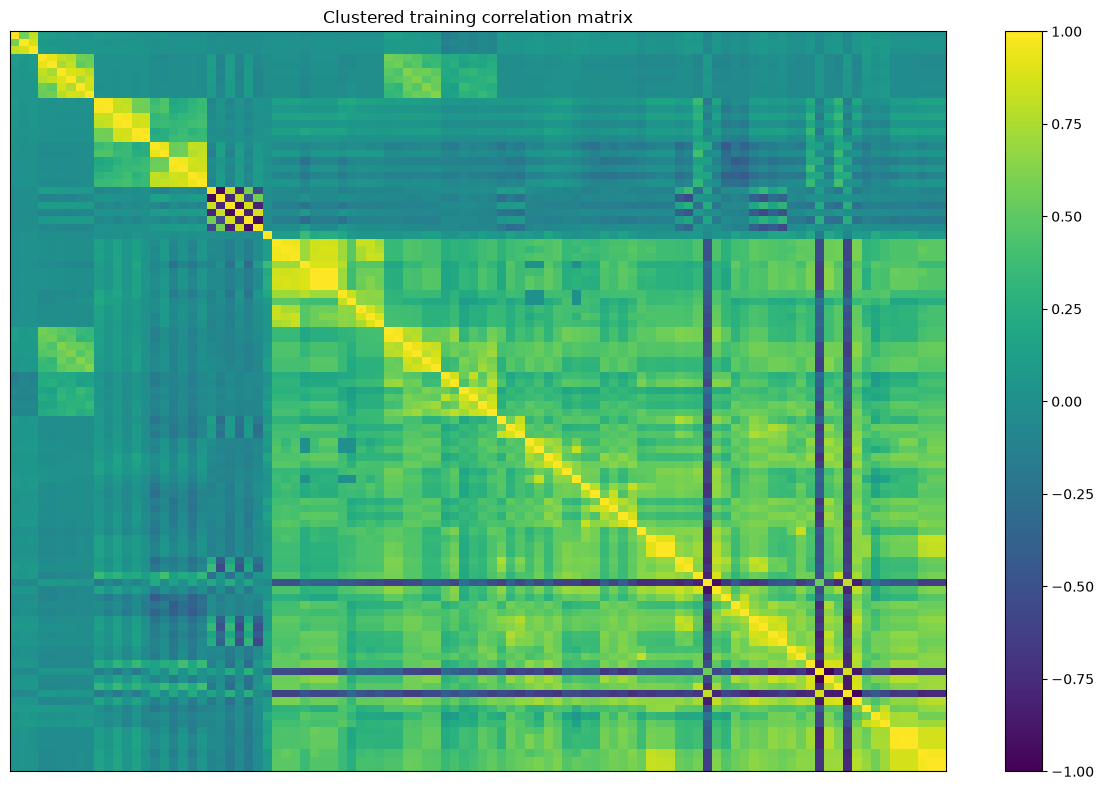

,feature1,feature2,corr,abs_corr,index_gap
0,x49,x52,0.999996,0.999996,3
1,x50,x53,0.999857,0.999857,3
2,x51,x54,0.999642,0.999642,3
3,x13,x16,0.997249,0.997249,3
4,x7,x16,0.994874,0.994874,9
5,x7,x13,0.994009,0.994009,6
6,x49,x55,0.988759,0.988759,6
7,x52,x55,0.988740,0.988740,3
8,x58,x61,-0.987044,0.987044,3
9,x81,x93,0.981349,0.981349,12


,n_pairs,median_abs_corr,p90_abs_corr,frac_gt_080
index_gap,,,,
1,99,0.818790,0.872724,0.636364
3,97,0.629066,0.940188,0.226804
2,98,0.558137,0.766949,0.071429
6,94,0.491680,0.841372,0.106383
30,70,0.482820,0.578557,0.000000
12,88,0.477858,0.717065,0.034091
9,91,0.471795,0.782792,0.098901
21,79,0.459784,0.630910,0.037975
33,67,0.453791,0.604650,0.000000


,count,mean,median
same_mod3,,,
False,3333,0.279061,0.276361
True,1617,0.340687,0.369206


In [7]:
corr, z, order = correlation_clustering(df, feature_cols, method='spearman')
plt.figure(figsize=(14, 5))
dendrogram(z, labels=feature_cols, leaf_rotation=90, leaf_font_size=6)
plt.title('Full-training feature dendrogram: 1 - |Spearman correlation|')
plt.tight_layout()
plt.show()
plt.close('all')
heatmap(corr.loc[order, order], 'Clustered training correlation matrix', labels=False, limits=(-1, 1))
plt.close('all')
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs = redundant_pairs(corr, threshold=.8)
display(pairs.head(30))
gap_pairs = pairs.dropna(subset=['index_gap']).copy()
gap_pairs['index_gap'] = gap_pairs.index_gap.astype(int)
all_pairs = redundant_pairs(corr, threshold=0).dropna(subset=['index_gap'])
all_pairs['index_gap'] = all_pairs.index_gap.astype(int)
gap_summary = all_pairs.groupby('index_gap').agg(
    n_pairs=('abs_corr', 'size'), median_abs_corr=('abs_corr', 'median'),
    p90_abs_corr=('abs_corr', lambda x: x.quantile(.9)),
    frac_gt_080=('abs_corr', lambda x: (x >= .8).mean()),
).sort_values('median_abs_corr', ascending=False)
all_pairs['same_mod3'] = all_pairs.index_gap.mod(3).eq(0)
mod3_summary = all_pairs.groupby('same_mod3').abs_corr.agg(['count', 'mean', 'median'])
display(gap_summary.head(20), mod3_summary)

## 4. Full-training autocorrelation

Ljung–Box(15) is applied directly to each feature, not regression residuals. Display and rank raw statistics, ACF(1), and per-feature observation counts; Q also grows with sample size. Missing values are omitted per feature: these are lags between successive observed values, not guaranteed five-minute clock intervals.

,feature,n,acf1,max_abs_acf_1_to_lag,lb_stat,lb_pvalue,lb_qvalue
56,x57,480744,0.989220,0.989220,4.578699e+06,0.0,0.0
41,x42,446749,0.989065,0.989065,4.307341e+06,0.0,0.0
65,x66,374281,0.988780,0.988780,3.650854e+06,0.0,0.0
77,x78,338776,0.990617,0.990617,3.395004e+06,0.0,0.0
5,x6,329833,0.987226,0.987226,3.214314e+06,0.0,0.0
2,x3,333875,0.987453,0.987453,3.203368e+06,0.0,0.0
59,x60,338841,0.986322,0.986322,3.135615e+06,0.0,0.0
8,x9,346261,0.976988,0.976988,2.935727e+06,0.0,0.0
55,x56,480744,0.963029,0.963029,2.612777e+06,0.0,0.0
40,x41,446749,0.963445,0.963445,2.431948e+06,0.0,0.0


Usable features: 100/100
Ljung-Box(15), FDR q<5%: 100/100


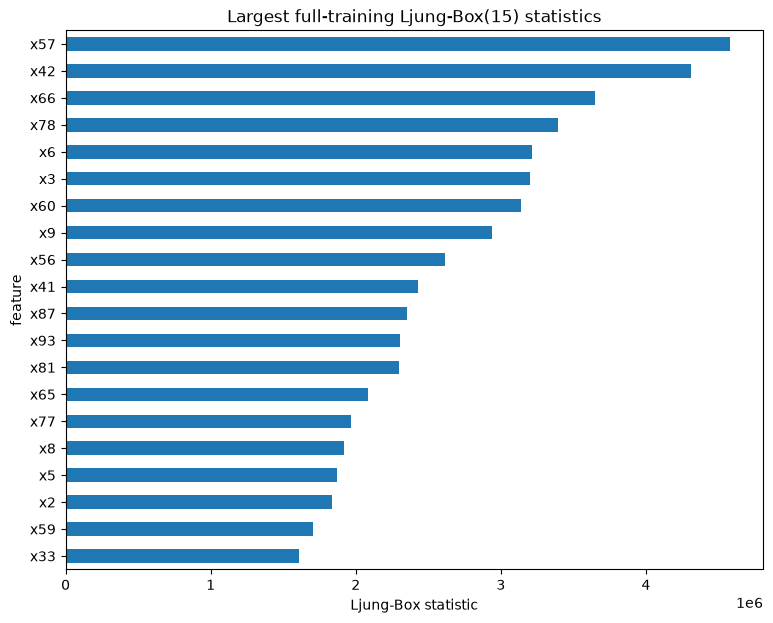

In [8]:
auto = autocorrelation_table(df, feature_cols, lag=ACF_LAG)
assert auto.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
display(auto.head(20))
print(f'Usable features: {auto.lb_stat.notna().sum()}/{len(auto)}')
print(f'Ljung-Box({ACF_LAG}), FDR q<5%: {(auto.lb_qvalue < .05).sum()}/{len(auto)}')
auto.head(20).sort_values('lb_stat').plot.barh(
    x='feature', y='lb_stat', figsize=(9, 7), legend=False,
    title=f'Largest full-training Ljung-Box({ACF_LAG}) statistics')
plt.xlabel('Ljung-Box statistic')
plt.show()
plt.close('all')

### 4.1 Longer-lag / seasonal ACF patterns

Repeated bands or peaks in the heatmap flag periodic structure. These are **row lags**: if source bars have gaps, lag 288 is not automatically a 24-hour clock-time lag.

,peak_lag,peak_acf
x30,16,0.624285
x18,16,0.618594
x78,16,0.607077
x87,16,0.605638
x33,16,0.591339
x6,16,0.591328
x84,16,0.589893
x93,16,0.589365
x66,16,0.588983
x81,16,0.585701


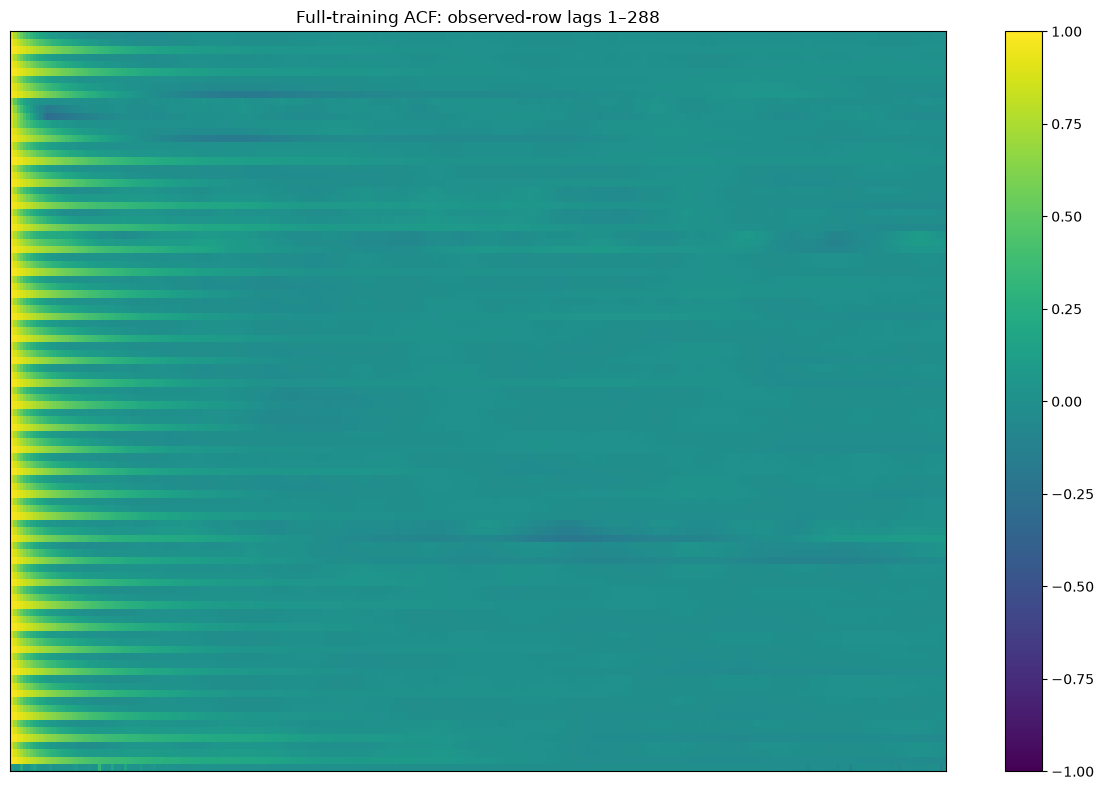

In [9]:
season_acf = acf_matrix(df, feature_cols, nlags=SEASONAL_NLAGS)
long_lag = season_acf.loc[ACF_LAG + 1:]
valid = long_lag.columns[long_lag.notna().any()]
peak_lag = long_lag[valid].abs().idxmax()
peak = pd.DataFrame({
    'peak_lag': peak_lag,
    'peak_acf': [long_lag.loc[peak_lag[c], c] for c in valid],
}).sort_values('peak_acf', key=lambda s: s.abs(), ascending=False)
display(peak.head(20))
heatmap(season_acf.loc[1:].T, 'Full-training ACF: observed-row lags 1–288', labels=False, limits=(-1, 1))
plt.close('all')

## 5. Training-period distribution shifts

Adjacent-month mean changes are scaled by the **training** standard deviation. The log standard-deviation ratio compares adjacent months. These are descriptive changes, not formal break-date estimates. All grouping now uses `msgStamp`; partial boundary months can have fewer observations.

,max_abs_monthly_mean_shift_z,max_abs_monthly_log_std_ratio
x27,1.194728,1.544659
x24,1.163821,1.561496
x99,1.127276,1.652901
x96,1.091659,1.706036
x30,1.075000,2.899247
x33,1.064781,1.325685
x39,1.005112,1.154962
x63,0.966948,1.200168
x36,0.896158,1.049421
x29,0.888844,2.891253


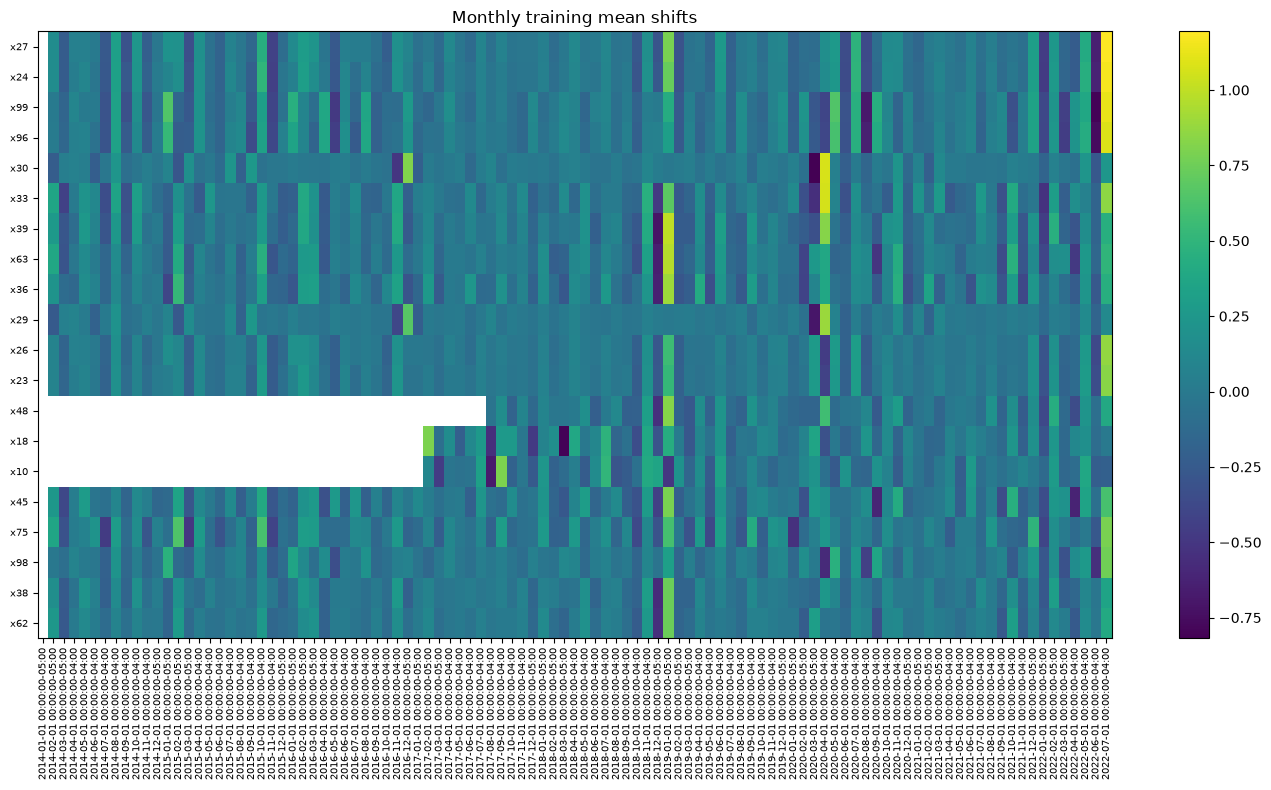

In [10]:
mean_shift, vol_shift = monthly_shift_scores(df.reset_index(), 'msgStamp', feature_cols)
breaks = pd.DataFrame({
    'max_abs_monthly_mean_shift_z': mean_shift.abs().max(),
    'max_abs_monthly_log_std_ratio': vol_shift.abs().max(),
}).sort_values('max_abs_monthly_mean_shift_z', ascending=False)
display(breaks.head(20))
heatmap(mean_shift[breaks.head(20).index].T, 'Monthly training mean shifts', figsize=(14, 8))
plt.close('all')

## 6. Cashflow: infer the definition from named fields

Only named numeric market variables are compared; `x*` features are deliberately excluded. Examine cashflow relative to volume as well as unconditional level correlations.

,wmid,adjMid,volume,cashflow,ret_5m
wmid,1.000000,0.999182,0.052109,0.008949,0.002637
adjMid,0.999182,1.000000,0.054724,0.008655,0.002669
volume,0.052109,0.054724,1.000000,-0.013539,0.008276
cashflow,0.008949,0.008655,-0.013539,1.000000,-0.016442
ret_5m,0.002637,0.002669,0.008276,-0.016442,1.000000


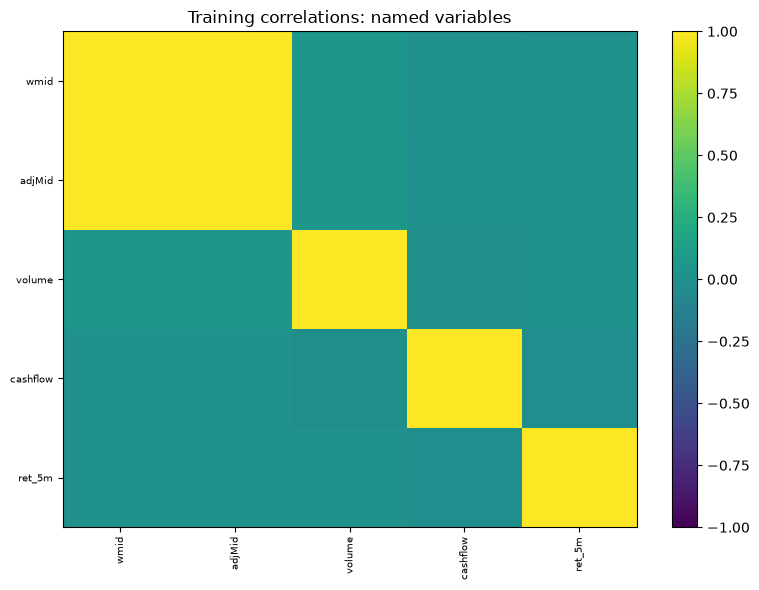

,spearman
adjMid,0.008655
wmid,0.008949
volume,-0.013539
ret_5m,-0.016442


In [11]:
named_numeric = [c for c in df.select_dtypes(include=np.number).columns
                 if c not in feature_cols and not c.startswith('_')]
named_corr = df[named_numeric].corr(method='spearman')
display(named_corr)
heatmap(named_corr, 'Training correlations: named variables', figsize=(8, 6), limits=(-1, 1))
plt.close('all')
cash_named = named_corr['cashflow'].drop('cashflow').sort_values(key=lambda x: x.abs()).to_frame('spearman')
display(cash_named)

### Cashflow-to-volume exceptions

Show rows where `abs(cashflow / volume) > 1`. Zero volume is not silently discarded: nonzero cashflow divided by zero appears as infinity and is included by this predicate. Display a deterministic sample of at most 20 rows, followed by all distinct dates and their exception counts. Only the display is sampled; the predicate and counts use every training row. No CSV is exported.

In [12]:
flow_ratio = df.cashflow / df.volume
cashflow_outliers = df.loc[flow_ratio.abs().gt(1), named_numeric].assign(cashflow_per_volume=flow_ratio)
print(f'{len(cashflow_outliers):,} / {len(df):,} training rows have |cashflow / volume| > 1')
print(f'Zero-volume rows: {df.volume.eq(0).sum():,}')
display(cashflow_outliers.sample(n=min(20, len(cashflow_outliers)), random_state=0).sort_index())
exception_dates = cashflow_outliers.groupby(cashflow_outliers.index.date).size().rename('exception_rows')
print(f'{len(exception_dates)} unique local dates; counts below cover ALL exceptions, not the sample.')
with pd.option_context('display.max_rows', None):
    display(exception_dates.to_frame())

551 / 640,734 training rows have |cashflow / volume| > 1
Zero-volume rows: 6,471


,wmid,adjMid,volume,cashflow,ret_5m,cashflow_per_volume
msgStamp,,,,,,
2014-06-17 16:50:00-04:00,1934.220064,2130.867951,27.0,-67.0,0.000000,-2.481481
2014-09-15 02:25:00-04:00,1970.387755,2179.424142,56.0,-73.0,0.000254,-1.303571
2014-09-16 22:55:00-04:00,1990.565287,2201.824010,112.0,-119.0,-0.000126,-1.062500
2014-09-17 01:20:00-04:00,1990.176295,2201.547468,12.0,17.0,-0.000126,1.416667
2014-09-17 23:55:00-04:00,1994.661082,2206.525217,38.0,39.0,-0.000125,1.026316
2015-06-16 19:15:00-04:00,2089.641304,2337.265800,50.0,-55.0,-0.000120,-1.100000
2016-12-14 01:40:00-05:00,2266.662963,2595.787951,34.0,-78.0,-0.000110,-2.294118
2017-06-15 01:25:00-04:00,2430.087766,2788.970317,92.0,-105.0,-0.000206,-1.141304
2018-09-18 00:35:00-04:00,2893.045918,3303.185874,140.0,148.0,0.000173,1.057143


92 unique local dates; counts below cover ALL exceptions, not the sample.


,exception_rows
2014-03-17,4
2014-03-18,4
2014-03-19,2
2014-03-20,1
2014-03-21,2
2014-06-15,4
2014-06-16,15
2014-06-17,10
2014-06-18,5
2014-06-19,5


### Volatility-scaled signed-flow diagnostic

**Working hypothesis:** cashflow is likely signed trade flow or quote imbalance, rather than an unsigned price-times-volume cash amount. This is a hypothesis, not a documented definition. Out-of-range ratios can also reflect unit, aggregation, or timestamp mismatches.

The expression below is the requested calculation. It clips the ratio to [-1, 1], scales by the previous row's EWM return standard deviation (`halflife=288*21`, pandas defaults), multiplies by the supplied return, then sums by calendar day and cumulatively. All state is learned inside training. Initial undefined volatility/contributions remain missing; pandas daily `sum()` uses its default behavior.

This curve is exploratory, not a validated strategy: the alignment of `ret_5m` with contemporaneous cashflow is unverified, and there are no execution delays or costs. Only the volatility denominator is lagged.

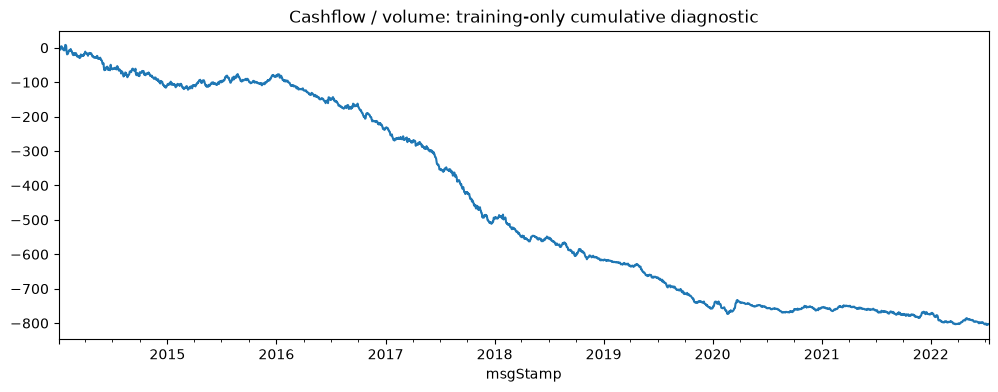

In [13]:
(df['cashflow'] / df['volume']).clip(-1, 1).div(
    df['ret_5m'].ewm(halflife=288*21).std().shift()
).mul(df['ret_5m']).resample('D').sum().cumsum().plot(
    figsize=(12, 4), title='Cashflow / volume: training-only cumulative diagnostic'
)
plt.show()
plt.close('all')

# Retain the same calculation for the summary and reproducibility checks.
flow_contribution = flow_ratio.clip(-1, 1).div(
    df.ret_5m.ewm(halflife=288*21).std().shift()
).mul(df.ret_5m)
flow_cumulative = flow_contribution.resample('D').sum().cumsum()

# Standalone feature importance

Assess each signal on its own with the requested exposure $x/\sigma_x^2$. This is **standalone performance**, not its unique incremental contribution after controlling for the other, often correlated, features. No sign is flipped and no test data are accessed.

Use every training row and every `x` column. The half-life and minimum number of non-null observations are both `288*21 = 6048`. EWM uses pandas defaults (`adjust=True`, `ignore_na=False`, sample-standard-deviation estimate); the current signal is included in its own scale. Only zero-volatility divisions are changed to missing to avoid infinite positions. There is no fitted leverage cap.

Daily `sum()` is retained exactly as requested: an all-missing day (including warm-up) becomes zero. The histogram uses **unannualized calendar-day mean/std**, not annualized trading-day Sharpe. Unequal feature availability means these are not common-sample or execution-adjusted comparisons. The coverage table below makes the differing sample lengths visible.

**Purple overlay:** each feature-family P&L panel includes its own lagged EWM-Sharpe combination, on a secondary right y-axis; its axis is independent of the component axis. Thin lines are individual portfolios; the thicker purple line is the actual combination, not a smoothed or rescaled illustration. Meta scores use intrabar P&L, half-life `252*288`, gross normalization across that whole family, and a one-row lag. Clip negative scores only for raw signals; allow signed scores for all transformed families. A normalized combination is not a sum of all member P&Ls and need not sit near the best individual line. No future performance is used to resize the overlay.

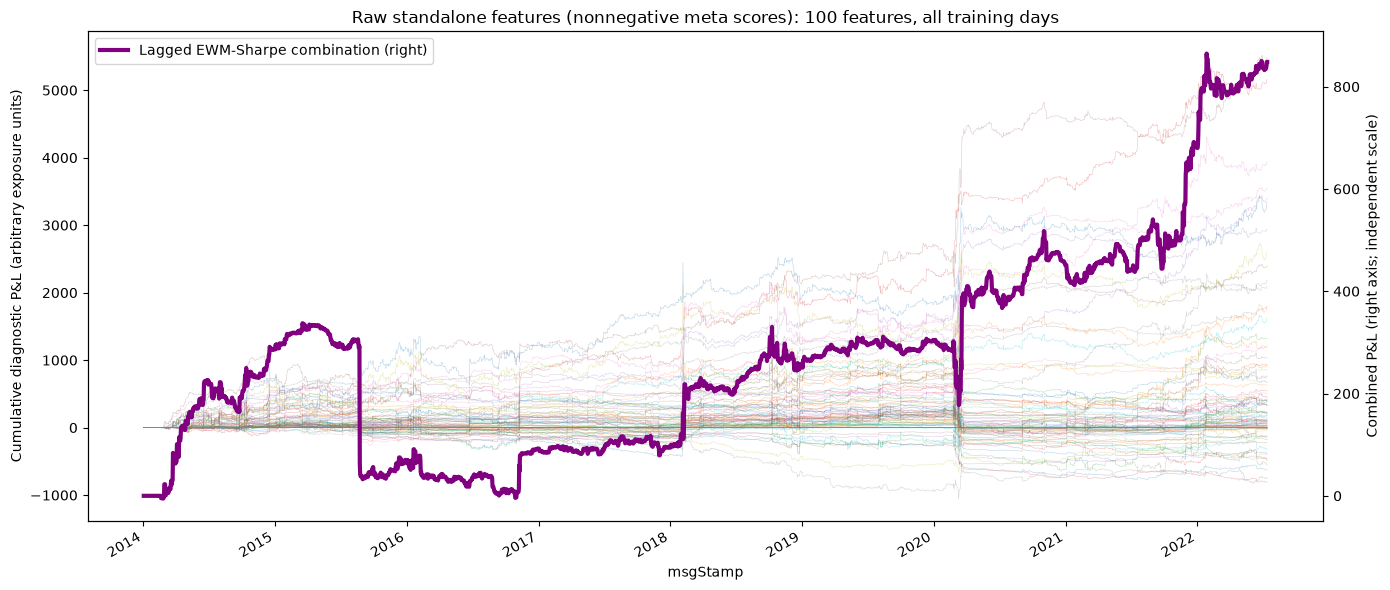

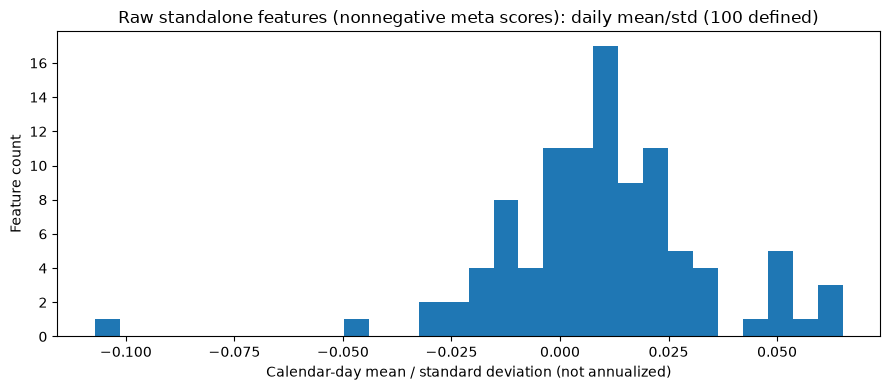

x1      0.012065
x2      0.019400
x3      0.018864
x4     -0.014375
x5     -0.000265
          ...   
x96     0.022154
x97     0.051007
x98     0.033993
x99     0.020591
x100   -0.107206
Length: 100, dtype: float64

In [14]:
from takehome.features import ts_std, ts_standardize, ts_zscore, sharpe, standalone_pnl

x_cols = df.head(0).filter(like='x').columns
HL = 288 * 21
# Equivalent to x.div(ts_std(x, HL)**2), then multiply returns by ROW.
pnl = standalone_pnl(df[x_cols], df['ret_5m'], hl=HL)
pnl_daily = pnl.resample('D').sum()
assert pnl.index.equals(df.index) and pnl.columns.equals(x_cols)
assert not np.isinf(pnl.to_numpy()).any()
from takehome.features import combine_pnls
from takehome.plots import display_results

META_HL = 252 * 288
raw_meta = combine_pnls(pnl, hl=META_HL, positive_only=True)
display_results(pnl_daily, 'Raw standalone features (nonnegative meta scores)',
                meta_daily=raw_meta.resample('D').sum())

In [15]:
standalone = pd.DataFrame({
    'daily_mean_over_std': pnl_daily.pipe(sharpe),
    'pnl_observations': pnl.count(),
    'days_with_observations': pnl.notna().resample('D').sum().gt(0).sum(),
    'first_pnl_msgStamp': pnl.apply(lambda x: x.first_valid_index()),
    'last_pnl_msgStamp': pnl.apply(lambda x: x.last_valid_index()),
}).sort_values('daily_mean_over_std', ascending=False)
with pd.option_context('display.max_rows', None):
    display(standalone)
print('Best/worst standalone DAILY mean/std:',
      standalone.daily_mean_over_std.max(), standalone.daily_mean_over_std.min())

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x94,0.065095,153523,2064,2014-04-29 12:15:00-04:00,2022-07-13 16:00:00-04:00
x76,0.063963,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x77,0.060185,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x86,0.055775,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x78,0.053404,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x85,0.051261,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x58,0.051148,332732,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x97,0.051007,147767,2058,2014-05-07 11:50:00-04:00,2022-07-13 16:00:00-04:00
x87,0.048338,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x95,0.047486,153523,2064,2014-04-29 12:15:00-04:00,2022-07-13 16:00:00-04:00


Best/worst standalone DAILY mean/std: 0.06509473315642564 -0.107206323248636


## Why feature volatility can proxy asset volatility

For a signed standardized signal, the intended idealized exposure is

$$w_{j,t}=\frac{\mathrm{ts\_standardize}(x_j)_t}{\sigma_{r,t}}
=\frac{x_{j,t}}{\sigma_{x_j,t}\,\sigma_{r,t}},\qquad
\mathrm{PnL}_{j,t}=w_{j,t}r_{t\to t+h}.$$

`ts_std(signal) / asset_vol` would be a different, unsigned exposure: it removes the direction of the signal. The expression above uses **ts_standardize**, not **ts_std**, in the numerator. Use `ts_zscore` instead only when removing the local signal mean is intentional.

Prices/realized returns are withheld in the final deployment period, so realized asset volatility cannot be refreshed there. If $\sigma_{x_j,t}\approx k_j\sigma_{r,t}$ with reasonably stable $k_j$, then $w_{j,t}\approx k_j x_{j,t}/\sigma_{x_j,t}^2$. Dropping the constant gives the requested diagnostic. This is a proxy assumption, not an identity; a changing feature amplitude, family or regime can break it. Fixed positive scale does not change mean/std but changes P&L units.

Weighting can alternatively enter the fitter. For WLS, $H=X(X^\top W X)^{-1}X^\top W$ already includes the observation weights in $\widehat y=Hy$. However, weighting historical residuals does **not automatically implement the same forecast-time inverse-volatility exposure**. Lasso does not have one fixed, response-independent hat matrix: the active set depends on the target. The initial fitter below therefore documents its weighting objective explicitly.

Only the feature history enters the signal scale. Nevertheless, the alignment/availability of the supplied `ret_5m` must be established before these curves can be described as executable forward-return backtests. They contain no costs or execution lag.

## Transform experiments

In this section **display results** means a separate cumulative daily P&L figure and a separate histogram of daily mean/std for each experiment. Each transformation is applied to the **raw** `x_cols`, independently of the others, before the same exposure rule:

$$z_t=\mathrm{transform}(x)_t,\qquad w_t=z_t/\widehat{\sigma}_{z,t}^{\,2},\qquad \mathrm{PnL}_t=w_t\,\mathrm{ret\_5m}_t.$$

The downstream EWM half-life and minimum observations remain `HL=288*21`. All training rows are used. Pairwise expansions are processed in small **column batches**, retaining only daily P&L and coverage, rather than materializing billions of intrabar values. No row or pair subsampling, sign flipping, or holdout access occurs. The input `ret_5m` is used only to evaluate P&L, never to build a transformation.

Warm-up/missing observations and zero variance stay missing before the same daily `sum()` convention. All-missing days become zero, undefined Sharpes are omitted from histograms and counted, and near-duplicate residuals can amplify numerical noise through the inverse-variance exposure. These are **standalone training diagnostics**, not estimates of a feature's unique contribution to a joint model. Many more pair candidates also create many more opportunities to obtain a good-looking training result by chance.

Each panel overlays the combination of that family only. The histogram continues to describe individual feature Sharpes; it does not add the combined portfolio as another feature.

In [16]:
from time import perf_counter
from takehome.features import dszl, pairwise_features, evaluate_features, combine_pnls
from takehome.plots import display_results

# The baseline table/daily series are retained; its large intrabar matrix is no longer needed.
del pnl
raw_features = df[x_cols]
experiment_seconds = {}
assert raw_features.index.equals(df.index) and df.index.max() < split['cutoff']

### Time-of-day standardization — dszl(hl=10)

Use `index.time` (local clock time in the supplied timezone), and standardize **the group**, not the outer DataFrame:

```python
X.groupby(X.index.time, group_keys=False).apply(
    lambda group: ts_standardize(group, hl=10)
).reindex(X.index)
```

There is no demeaning. Half-life 10 means **ten occurrences of the same clock time**, not ten adjacent five-minute bars; each group needs ten non-null values. A second `HL=6048` EWM standard deviation is then applied to the transformed signal by the existing P&L rule. The current feature observation is included in its feature-only scale, as for the raw baseline. Reindexing restores chronological order without filling missing values.

Reference: [pandas EWM weighting and missing-value conventions](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html).

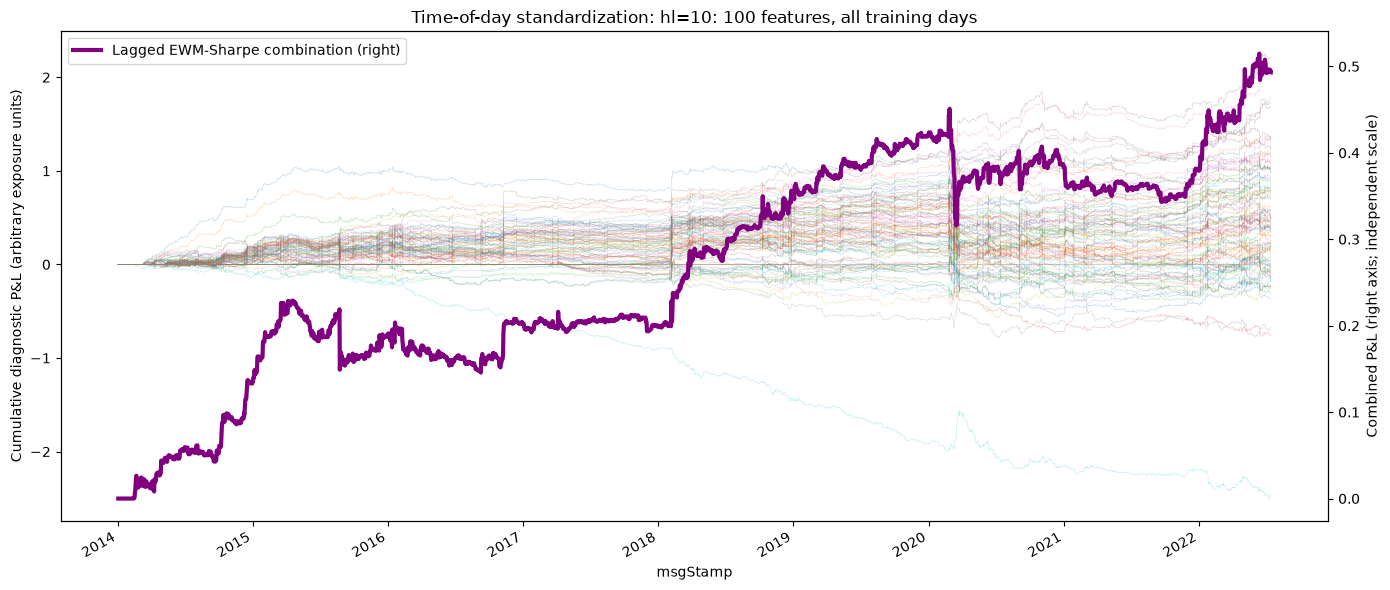

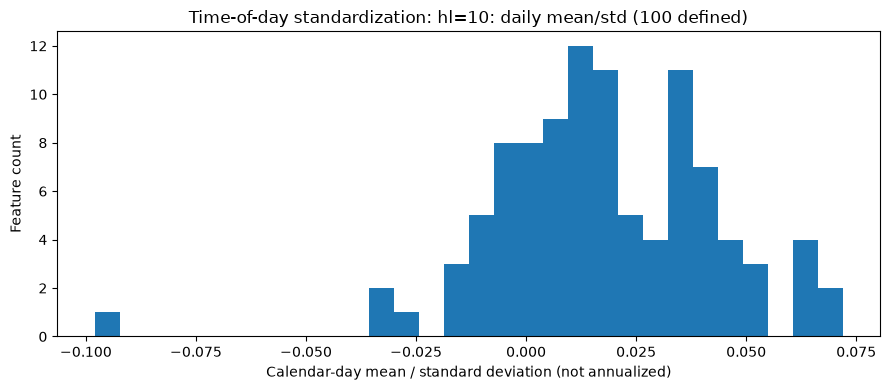

Top 10 by training daily mean/std; coverage differs by feature.


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x76,0.071894,331263,2154,2014-03-11 14:00:00-04:00,2022-07-13 16:00:00-04:00
x77,0.068168,331263,2154,2014-03-11 14:00:00-04:00,2022-07-13 16:00:00-04:00
x85,0.064278,227904,2137,2014-04-03 16:00:00-04:00,2022-07-13 16:00:00-04:00
x86,0.062873,227904,2137,2014-04-03 16:00:00-04:00,2022-07-13 16:00:00-04:00
x78,0.062152,331263,2154,2014-03-11 14:00:00-04:00,2022-07-13 16:00:00-04:00
x94,0.061240,152821,2055,2014-05-12 14:45:00-04:00,2022-07-13 16:00:00-04:00
x97,0.053101,147065,2047,2014-05-22 10:35:00-04:00,2022-07-13 16:00:00-04:00
x87,0.053063,227904,2137,2014-04-03 16:00:00-04:00,2022-07-13 16:00:00-04:00
x51,0.049782,165157,2107,2014-05-05 10:45:00-04:00,2022-07-13 16:15:00-04:00
x95,0.048163,152821,2055,2014-05-12 14:45:00-04:00,2022-07-13 16:00:00-04:00


In [17]:
started = perf_counter()
dszl_daily, dszl_summary, dszl_meta = evaluate_features(
    [dszl(raw_features, hl=10)], df['ret_5m'], hl=HL, meta=True, meta_hl=META_HL,
)
experiment_seconds['dszl(10)'] = perf_counter() - started
assert dszl_daily.shape[1] == len(x_cols)
display_results(dszl_daily, 'Time-of-day standardization: hl=10',
                meta_daily=dszl_meta.resample('D').sum())
print('Top 10 by training daily mean/std; coverage differs by feature.')
display(dszl_summary.head(10))

### Two-way interactions — products of distinct raw features

Use $z_{ij,t}=x_{i,t}x_{j,t}$ for every $i<j$: **4,950 products** for 99 predictors. Squares and duplicate reverse-order products are excluded. These are raw products, not products of the dszl signals and not demeaned products. Missing either input makes the product missing. The following P&L scaling uses the **product's own** EWM variance.

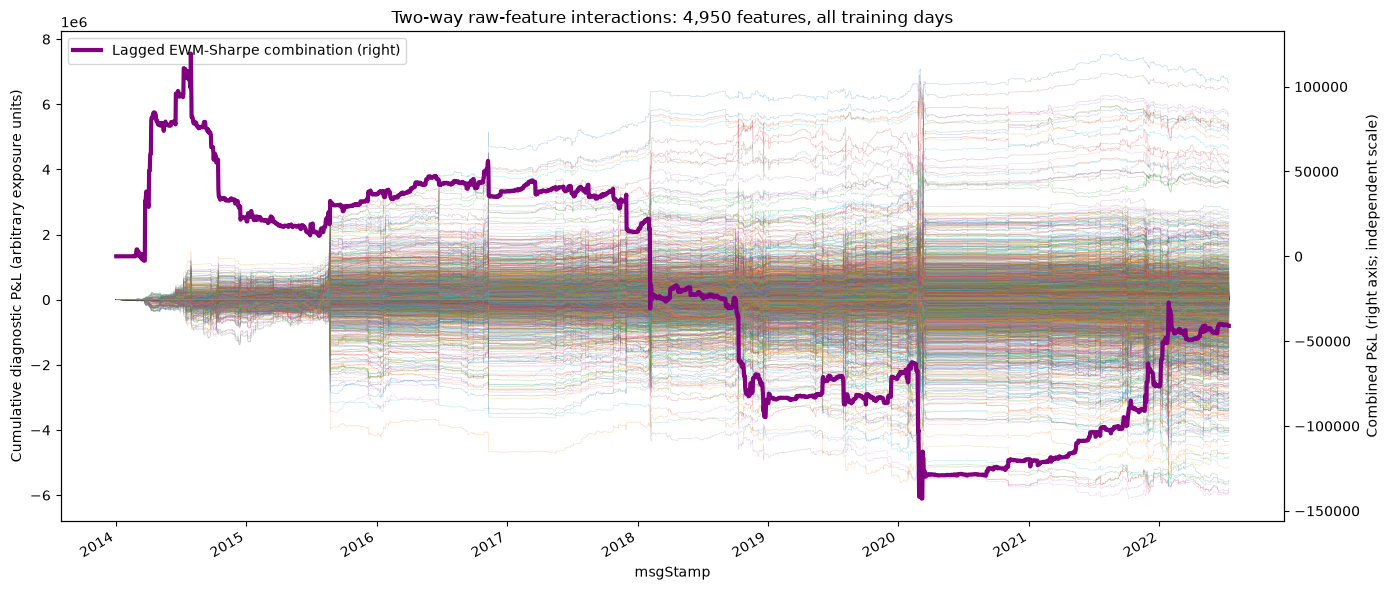

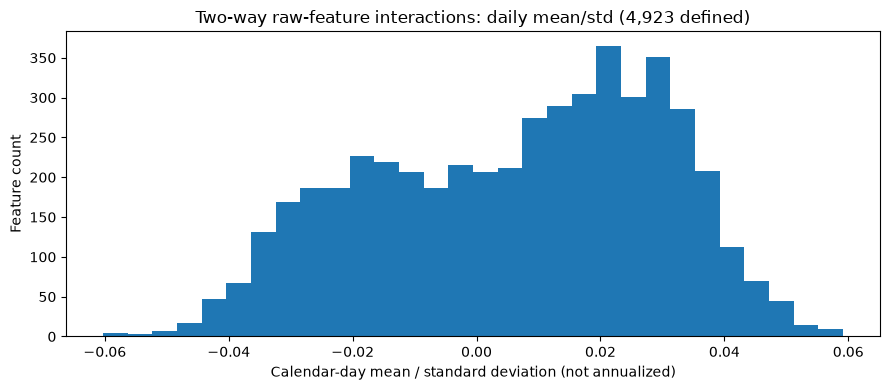

Top 10 of all distinct products; this is a training screen, not feature selection.


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x54*x61,0.059147,161365,2114,2014-04-24 10:15:00-04:00,2022-07-13 15:55:00-04:00
x51*x61,0.059056,161365,2114,2014-04-24 10:15:00-04:00,2022-07-13 15:55:00-04:00
x19*x57,0.057954,157344,2062,2014-04-25 15:35:00-04:00,2022-07-13 15:55:00-04:00
x31*x51,0.056310,159550,2063,2014-04-24 15:40:00-04:00,2022-07-13 15:55:00-04:00
x31*x72,0.056268,148951,2058,2014-05-07 15:20:00-04:00,2022-07-13 16:00:00-04:00
x57*x61,0.056248,161365,2114,2014-04-24 10:15:00-04:00,2022-07-13 15:55:00-04:00
x31*x54,0.056064,159550,2063,2014-04-24 15:40:00-04:00,2022-07-13 15:55:00-04:00
x32*x72,0.055963,148951,2058,2014-05-07 15:20:00-04:00,2022-07-13 16:00:00-04:00
x4*x54,0.055326,156930,2049,2014-04-25 10:15:00-04:00,2022-07-13 15:55:00-04:00
x37*x100,0.055129,162141,2106,2014-04-23 15:40:00-04:00,2022-07-13 16:00:00-04:00


In [18]:
started = perf_counter()
interaction_daily, interaction_summary, interaction_meta = evaluate_features(
    pairwise_features(raw_features, kind='product', batch_size=8),
    df['ret_5m'], hl=HL, meta=True, meta_hl=META_HL,
)
experiment_seconds['Raw products'] = perf_counter() - started
assert interaction_daily.shape[1] == len(x_cols) * (len(x_cols) - 1) // 2
display_results(interaction_daily, 'Two-way raw-feature interactions',
                meta_daily=interaction_meta.resample('D').sum())
print('Top 10 of all distinct products; this is a training screen, not feature selection.')
display(interaction_summary.head(10))

### Pairwise residuals — online lasso with alpha=0, W=1

Use both directions for every pair: **9,900 residual series**. The name `x_i~x_j` means the residual of raw `x_i` regressed on raw `x_j`, with an intercept. Its reverse is a different experiment.

The existing `StreamingWeightedLasso` is used with `n_features=1`, `alpha=0` (the implementation's regularization parameter), `fit_intercept=True`, and `decay=2**(-1/6048)`. Each jointly finite pair receives unit observation weight; missing rows receive zero weight but still advance the original row clock. No price, return or notional weights enter these regressions.

For a residual at row $t$, fit only earlier jointly observed raw pairs:

$$ (a_{t-1},b_{t-1})=\arg\min_{a,b}\sum_{s<t}d^{t-1-s}I_s(x_{i,s}-a-bx_{j,s})^2,$$
$$z_{i\mid j,t}=x_{i,t}-a_{t-1}-b_{t-1}x_{j,t}.$$

Require two prior joint observations; the downstream P&L still needs 6,048 non-null residual observations. The shifted coefficient/intercept histories ensure the current response does not fit away its own residual. This differs from using post-update/in-sample regression residuals. It removes the historical relationship with **one** other predictor, not all predictors jointly.

For one predictor and `alpha=0`, the fitter uses the exact scalar solution $b=C_{xy}/C_{xx}$, $a=\bar y-b\bar x$, from the same weighted centered sufficient statistics. This is a fast path inside the existing fitter, not an approximate substitute or a separate estimator. Tests reconcile it with direct weighted least squares and the previous coordinate-descent path, including skipped rows, intercepts, and pre-update timing.

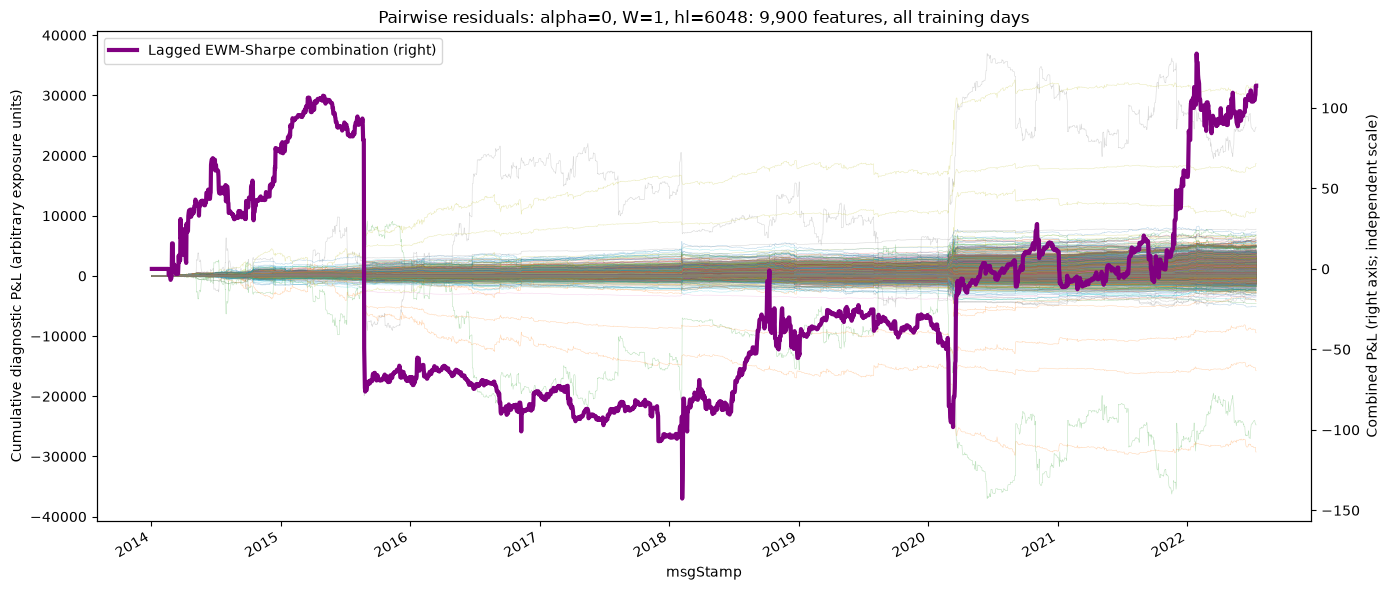

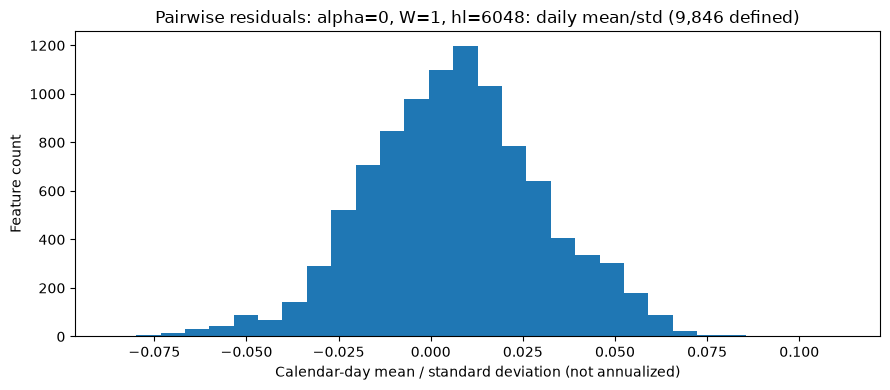

Top 10 of both directed residuals; near-collinear pairs require numerical caution.


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x2~x58,0.111979,327770,2130,2014-02-26 12:10:00-05:00,2022-07-13 16:00:00-04:00
x1~x58,0.101566,327770,2130,2014-02-26 12:10:00-05:00,2022-07-13 16:00:00-04:00
x58~x1,0.097190,327770,2130,2014-02-26 12:10:00-05:00,2022-07-13 16:00:00-04:00
x58~x2,0.096267,327770,2130,2014-02-26 12:10:00-05:00,2022-07-13 16:00:00-04:00
x58~x41,0.091115,283802,2013,2014-03-20 05:15:00-04:00,2022-07-13 16:00:00-04:00
x58~x64,0.082851,203024,2105,2014-05-07 03:20:00-04:00,2022-07-13 13:00:00-04:00
x58~x40,0.082396,283802,2013,2014-03-20 05:15:00-04:00,2022-07-13 16:00:00-04:00
x56~x58,0.081635,321308,2151,2014-03-06 14:20:00-05:00,2022-07-13 15:55:00-04:00
x19~x61,0.081079,157796,2066,2014-04-25 15:45:00-04:00,2022-07-13 16:00:00-04:00
x2~x59,0.080299,327770,2130,2014-02-26 12:10:00-05:00,2022-07-13 16:00:00-04:00


In [19]:
started = perf_counter()
residual_daily, residual_summary, residual_meta = evaluate_features(
    pairwise_features(raw_features, kind='residual', hl=HL, batch_size=8),
    df['ret_5m'], hl=HL, meta=True, meta_hl=META_HL,
)
experiment_seconds['Pair residuals'] = perf_counter() - started
assert residual_daily.shape[1] == len(x_cols) * (len(x_cols) - 1)
display_results(residual_daily, 'Pairwise residuals: alpha=0, W=1, hl=6048',
                meta_daily=residual_meta.resample('D').sum())
print('Top 10 of both directed residuals; near-collinear pairs require numerical caution.')
display(residual_summary.head(10))

### Training-only comparison

Compare the distributions, not only their maxima: raw predictors have 99 candidates, whereas products/residuals have thousands. These are unannualized calendar-day mean/std ratios under the requested missing-day convention. Availability differs; cumulative P&L units also differ after nonlinear transformations. This table does not establish out-of-sample improvement. No test data have been used.

In [20]:
experiment_summaries = {
    'Raw baseline': standalone, 'dszl(10)': dszl_summary,
    'Raw products': interaction_summary, 'Pair residuals': residual_summary,
}
comparison_rows = {}
for name, table in experiment_summaries.items():
    s = table['daily_mean_over_std'].dropna()
    comparison_rows[name] = {
        'candidates': len(table), 'defined_sharpes': len(s),
        'median_daily_sharpe': s.median(), 'p95_daily_sharpe': s.quantile(.95),
        'max_daily_sharpe': s.max(), 'min_daily_sharpe': s.min(),
        'positive_fraction': s.gt(0).mean(), 'compute_seconds': experiment_seconds.get(name, np.nan),
    }
transformation_comparison = pd.DataFrame.from_dict(comparison_rows, orient='index')
display(transformation_comparison)
print(transformation_comparison.to_string())
print('Train-only rows:', len(df), '; final training timestamp:', df.index.max())
for name, table in experiment_summaries.items():
    print('\n', name, 'top 5 (training diagnostics)')
    print(table.head(5).to_string())
assert len(df) == split['train_rows'] and df.index.max() < split['cutoff']

,candidates,defined_sharpes,median_daily_sharpe,p95_daily_sharpe,max_daily_sharpe,min_daily_sharpe,positive_fraction,compute_seconds
Raw baseline,100,100,0.009593,0.051368,0.065095,-0.107206,0.700000,NaN
dszl(10),100,100,0.016045,0.061286,0.071894,-0.098027,0.740000,4.984962
Raw products,4950,4923,0.009746,0.039275,0.059147,-0.060267,0.613650,221.129589
Pair residuals,9900,9846,0.006628,0.047934,0.111979,-0.086551,0.609791,639.227099


                candidates  defined_sharpes  median_daily_sharpe  p95_daily_sharpe  max_daily_sharpe  min_daily_sharpe  positive_fraction  compute_seconds
Raw baseline           100              100             0.009593          0.051368          0.065095         -0.107206           0.700000              NaN
dszl(10)               100              100             0.016045          0.061286          0.071894         -0.098027           0.740000         4.984962
Raw products          4950             4923             0.009746          0.039275          0.059147         -0.060267           0.613650       221.129589
Pair residuals        9900             9846             0.006628          0.047934          0.111979         -0.086551           0.609791       639.227099
Train-only rows: 640734 ; final training timestamp: 2022-07-14 00:30:00-04:00

 Raw baseline top 5 (training diagnostics)
     daily_mean_over_std  pnl_observations  days_with_observations        first_pnl_msgStamp         la

## Ad hoc lagged EWM-Sharpe combination summary

Estimate each component's score from its **intrabar diagnostic P&L**, not daily P&L:

$$s_{j,t}=\frac{\mathrm{EWMmean}(p_j)_t}{\mathrm{EWMstd}(p_j)_t},\quad
m_{j,t}=\frac{s_{j,t}}{\sum_k |s_{k,t}|},\quad
p_t^{\rm meta}=\sum_j m_{j,t-1}p_{j,t}.$$

Use `halflife=252*288 = 72576` rows and pandas default EWM warm-up. Clip negative scores only for the **raw baseline**; keep signed scores for dszl, products and residuals. Scores with zero/undefined volatility get zero allocation. A zero gross denominator means no position. This fixes the sketch's invalid `hl=` EWM keyword and makes row-wise normalization and the final sum across signals explicit.

```python
moments = pnls.ewm(halflife=252*288)
score = moments.mean().div(moments.std().replace(0, np.nan)).fillna(0)
# Raw signals only: score = score.clip(lower=0)
meta_w = score.div(score.abs().sum(axis=1).replace(0, np.nan), axis=0)
combined = meta_w.shift().mul(pnls).sum(axis=1)
combined.resample('D').sum().cumsum().plot()
```

Pair computations normalize across **all candidates**, not separately inside each eight-column batch. The additive lagged numerator/gross calculation is algebraically identical to the dense formula and is tested against it. Missing current P&L contributes zero without redistributing its previously chosen allocation. Missing values do not count as artificial zero observations when estimating EWM moments.

These are training-only, ad hoc combinations. There is no alpha-sign selection using the full sample, no cost model, no covariance adjustment, and no holdout access. One-row lag is adequate only if the component's preceding P&L is actually observable then; `ret_5m` label availability remains a separate contract. An in-sample adaptive baseline is not a validated out-of-sample Sharpe. The half-life is in rows, not exactly a calendar year.

The actual combined P&L is highlighted in purple in each corresponding family panel above. This section retains the numerical cross-family comparison; raw cumulative P&L magnitudes are not comparable across different exposure units.

In [21]:
meta_pnls = pd.concat({
    'Raw (positive scores)': raw_meta, 'dszl(10) (signed)': dszl_meta,
    'Products (signed)': interaction_meta, 'Residuals (signed)': residual_meta,
}, axis=1)
assert meta_pnls.index.equals(df.index) and np.isfinite(meta_pnls.to_numpy()).all()
meta_daily = meta_pnls.resample('D').sum()
meta_summary = pd.DataFrame({
    'daily_mean_over_std': sharpe(meta_daily), 'daily_mean': meta_daily.mean(),
    'daily_std': meta_daily.std(), 'nonzero_bars': meta_pnls.ne(0).sum(),
    'cumulative_pnl': meta_daily.sum(),
})
display(meta_summary)
print('META_COMBINATIONS'); print(meta_summary.to_string())

,daily_mean_over_std,daily_mean,daily_std,nonzero_bars,cumulative_pnl
Raw (positive scores),0.037093,0.272291,7.340688,445718,848.459231
dszl(10) (signed),0.044996,0.000158,0.003517,489189,0.493132
Products (signed),-0.006022,-13.154921,2184.575407,448367,-40990.734744
Residuals (signed),0.009878,0.036547,3.699961,448365,113.878971


META_COMBINATIONS
                       daily_mean_over_std  daily_mean    daily_std  nonzero_bars  cumulative_pnl
Raw (positive scores)             0.037093    0.272291     7.340688        445718      848.459231
dszl(10) (signed)                 0.044996    0.000158     0.003517        489189        0.493132
Products (signed)                -0.006022  -13.154921  2184.575407        448367   -40990.734744
Residuals (signed)                0.009878    0.036547     3.699961        448365      113.878971


# Walk-forward regression backtests

Use all **100** raw predictors (including x100), W=1 on available targets, and the existing explicit zero-imputation of missing predictors. No target is imputed and every row advances decay. Keep the reserved final 20% untouched.

The only backtest is $p_t=\hat y_t/\mathrm{EWMstd}_{6048}(\hat y)_t^2\times\mathrm{ret\_5m}_t$. There is no extra forecast shift, cost model or leverage cap. Undefined divisions stay missing. Daily Sharpe means **unannualized calendar-day mean/std**.

## Objective and shared interface

With $a_{i,t}=W_i d^{t-i}$, $A=\sum a_i$ and weighted population feature scales $s_j$, the lasso loss is
$$\frac{1}{2A}\sum_i a_i(y_i-b-x_i^\top\beta)^2+\alpha\sum_j s_j|\beta_j|.$$
Ridge replaces the last term by $\alpha\sum_j(s_j\beta_j)^2/2$. Both leave the intercept unpenalized. All scales/means are fitted inside the previous training window.

`StreamingWeightedLasso_` is a real Numba jitclass owning state and compiled methods. `StreamingWeightedLasso` validates inputs, warns on nonconvergence, and exposes the familiar history and prediction interface. Welford/coordinate-descent mathematics is unchanged; forecasts are emitted directly in the compiled row loop before incorporating that row's label.

`BatchLasso` solves an independent CVXPY quadratic program from batch-recomputed moments. `CvxpyWeightedLasso` retains the original-row residual loss as a separate reference. `BatchRidge` solves the normal equations. `walk_forward_sweep` shares batch moments across penalties, not fitted parameters across evaluation rows. `BatchedFitters.get_coefs(lag=1)` and `get_intercepts(lag=1)` reconstruct its OOS `prediction_`.

## Fold and hyperparameter contract

Use an expanding training window, first fit after **72,576 input rows**, and hold its coefficients fixed over the next **6,048 rows**, then refit. These are row counts, not exact calendar months. Both batch models and streaming lasso use decay $d=2^{-1/6048}$, so matching cutoff fits have the same effective weighted history. `gap=0` still excludes the current prediction row; the prior row's label is assumed available, as in the requested beta.shift convention. Increase gap if the actual target maturity requires it.

Every sweep point is scored on forecasts from a previous fold, not fitted values. Grid values are fixed in advance; no best-alpha selection is claimed to be unbiased after viewing these validation scores. These are **walk-forward validation results inside the training 80%**, not results on the reserved test block. The first 6,048 OOS forecasts warm the common variance estimator; all models use the same subsequent evaluation span.

In [22]:
from takehome.fitters import (StreamingWeightedLasso, BatchRidge, BatchLasso,
                              CvxpyWeightedLasso, BatchedFitters, walk_forward_sweep,
                              walk_forward_folds, stream_at_folds, batch_moments, _scaled_moments)
from takehome.features import backtest, forecast_metrics
from takehome.plots import plot_calibration
from time import perf_counter

fit_columns = list(x_cols)
assert len(fit_columns) == 100 and fit_columns[-1] == 'x100'
X_fit = df[fit_columns].replace([np.inf,-np.inf], np.nan).fillna(0).to_numpy(dtype=float)
X_fit = np.ascontiguousarray(X_fit)
y_fit = df.ret_5m.to_numpy(dtype=float)
valid_fit = np.isfinite(y_fit)
W_fit = valid_fit.astype(float)
DECAY, DEFAULT_ALPHA, RIDGE_ALPHA = 2**(-1/HL), 1e-5, 1e-2
LASSO_ALPHAS = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4])
RIDGE_ALPHAS = np.logspace(-6, 2, 9)
FOLD = dict(min_train_size=252*288, step=21*288, train_size=None, gap=0)
folds = walk_forward_folds(len(df), **FOLD)
OOS_FIRST = folds[0]['predict_start']
SCORE_FIRST = OOS_FIRST + HL - 1
rows = np.arange(len(df))
score_day = df.index[SCORE_FIRST].normalize()

def oos_series(values):
    return pd.Series(values, index=df.index).where(rows >= OOS_FIRST)

def score_prediction(prediction):
    per_bar = backtest(prediction, df.ret_5m, HL).where(rows >= SCORE_FIRST)
    daily = per_bar.resample('D').sum().loc[score_day:]
    stats = forecast_metrics(prediction.iloc[SCORE_FIRST:], df.ret_5m.iloc[SCORE_FIRST:])
    return daily, dict(daily_sharpe=sharpe(daily), pnl_observations=int(per_bar.count()), **stats)

fold_table = pd.DataFrame(folds)
for key in ['train_start','train_stop','predict_start','predict_stop']:
    fold_table[key+'_msgStamp'] = [df.index[min(int(v),len(df)-1)] for v in fold_table[key]]
display(fold_table.head(8))
print(f'WF_PROTOCOL: {len(folds)} folds; {len(df)} training rows; {len(fit_columns)} predictors')
print('First OOS forecast:', df.index[OOS_FIRST], '; first scoring row:', df.index[SCORE_FIRST])
print('Valid target rows:', int(W_fit.sum()), '; x100 finite rows:', int(df.x100.notna().sum()))


,train_start,train_stop,predict_start,predict_stop,train_start_msgStamp,train_stop_msgStamp,predict_start_msgStamp,predict_stop_msgStamp
0,0,72576,72576,78624,2014-01-02 06:05:00-05:00,2014-12-22 06:05:00-05:00,2014-12-22 06:05:00-05:00,2015-01-20 06:05:00-05:00
1,0,78624,78624,84672,2014-01-02 06:05:00-05:00,2015-01-20 06:05:00-05:00,2015-01-20 06:05:00-05:00,2015-02-18 06:05:00-05:00
2,0,84672,84672,90720,2014-01-02 06:05:00-05:00,2015-02-18 06:05:00-05:00,2015-02-18 06:05:00-05:00,2015-03-19 06:05:00-04:00
3,0,90720,90720,96768,2014-01-02 06:05:00-05:00,2015-03-19 06:05:00-04:00,2015-03-19 06:05:00-04:00,2015-04-17 06:05:00-04:00
4,0,96768,96768,102816,2014-01-02 06:05:00-05:00,2015-04-17 06:05:00-04:00,2015-04-17 06:05:00-04:00,2015-05-18 06:05:00-04:00
5,0,102816,102816,108864,2014-01-02 06:05:00-05:00,2015-05-18 06:05:00-04:00,2015-05-18 06:05:00-04:00,2015-06-16 06:05:00-04:00
6,0,108864,108864,114912,2014-01-02 06:05:00-05:00,2015-06-16 06:05:00-04:00,2015-06-16 06:05:00-04:00,2015-07-15 06:05:00-04:00
7,0,114912,114912,120960,2014-01-02 06:05:00-05:00,2015-07-15 06:05:00-04:00,2015-07-15 06:05:00-04:00,2015-08-13 06:05:00-04:00


WF_PROTOCOL: 94 folds; 640734 training rows; 100 predictors
First OOS forecast: 2014-12-22 06:05:00-05:00 ; first scoring row: 2015-01-20 06:00:00-05:00
Valid target rows: 590635 ; x100 finite rows: 592734


## Numerical reference: direct CVXPY residual loss

This synthetic check uses exactly matched prefix observations, decay, feature-scaled penalty and intercept convention. The later real-data checks separately compare whole-history batch moments and frozen forecasts.

In [23]:
# Independent CVXPY loss at identical prefixes; no Numba Gram/CD reuse.
from takehome.fitters import StreamingWeightedLasso, CvxpyWeightedLasso, BatchedFitters

rng = np.random.default_rng(42)
X_check = rng.normal(size=(256, 4)) * [1, 2, 3, 4] + .3
y_check = .2 + X_check @ np.array([.6, 0, -.3, .15]) + rng.normal(size=256) * .1
v_check = (rng.uniform(1800, 2200, 256) * rng.lognormal(4, 1, 256))**2
decay, alpha = .99, .05
verification = []
for with_intercept in [False, True]:
    online = StreamingWeightedLasso(4, decay, alpha, max_iter=50000, tol=1e-11,
                                    fit_intercept=with_intercept, store_history=True).fit(X_check, y_check, W=v_check)
    for n in [32, 64, 128, 256]:
        ref = CvxpyWeightedLasso(4, decay, alpha, fit_intercept=with_intercept, tol=1e-12)
        ref.fit(X_check[:n], y_check[:n], W=v_check[:n])
        beta, bias = online.get_coefs()[n-1], online.get_intercepts()[n-1]
        a = v_check[:n] * decay**np.arange(n-1, -1, -1); a /= a.sum()
        loss_online = .5 * (a @ (y_check[:n] - X_check[:n] @ beta - bias)**2)
        loss_online += alpha * np.sum(ref.scale_ * np.abs(beta))
        verification.append({
            'intercept': with_intercept, 'prefix_rows': n,
            'max_coefficient_error': np.max(np.abs(beta-ref.coef)),
            'max_prediction_error': np.max(np.abs(X_check[:n] @ beta+bias-ref.predict(X_check[:n]))),
            'objective_gap': abs(loss_online-ref.objective_), 'cvxpy_status': ref.status_,
        })
    assert online.n_failed_ == 0
verification = pd.DataFrame(verification)
with pd.option_context('display.float_format', '{:.3e}'.format):
    display(verification)
print('CVXPY_RECONCILIATION'); print(verification.to_string(index=False))
assert verification.max_coefficient_error.max() < 5e-7
assert verification.max_prediction_error.max() < 2e-6
assert verification.objective_gap.max() < 1e-9

,intercept,prefix_rows,max_coefficient_error,max_prediction_error,objective_gap,cvxpy_status
0,False,32,9.180e-12,1.798e-11,9.798e-15,optimal
1,False,64,2.430e-12,1.106e-11,1.870e-13,optimal
2,False,128,7.286e-11,2.514e-10,1.388e-17,optimal
3,False,256,1.121e-11,6.500e-11,3.873e-14,optimal
4,True,32,3.299e-11,6.444e-11,1.388e-17,optimal
5,True,64,1.580e-11,5.286e-11,4.577e-14,optimal
6,True,128,3.774e-11,1.281e-10,7.340e-14,optimal
7,True,256,1.708e-11,7.006e-11,1.601e-13,optimal


CVXPY_RECONCILIATION
 intercept  prefix_rows  max_coefficient_error  max_prediction_error  objective_gap cvxpy_status
     False           32           9.179768e-12          1.797673e-11   9.797718e-15      optimal
     False           64           2.429501e-12          1.106049e-11   1.870171e-13      optimal
     False          128           7.286183e-11          2.513921e-10   1.387779e-17      optimal
     False          256           1.121292e-11          6.499645e-11   3.873291e-14      optimal
      True           32           3.299450e-11          6.443518e-11   1.387779e-17      optimal
      True           64           1.579625e-11          5.286119e-11   4.576894e-14      optimal
      True          128           3.774026e-11          1.281258e-10   7.339962e-14      optimal
      True          256           1.708045e-11          7.005918e-11   1.600664e-13      optimal


## Batch Ridge and batch lasso: next-fold OOS sweeps

One batch moment calculation per cutoff and decay is reused across the penalty grid. No future rows enter that calculation. Each fitted model is frozen over its next prediction fold; an expanding-window fit is never applied backward to its own training rows.

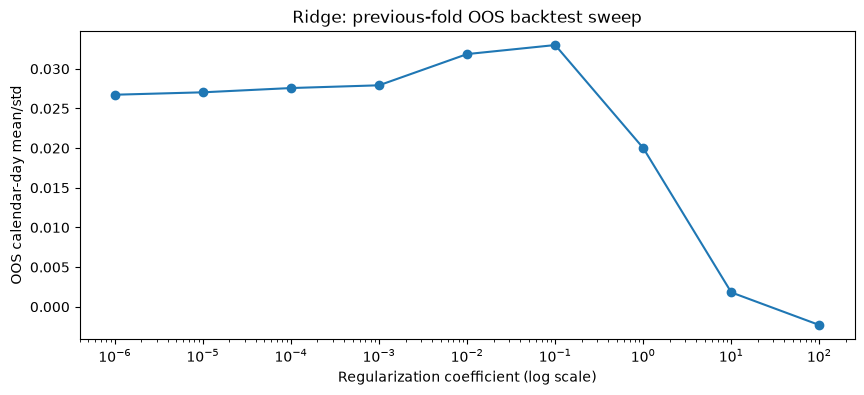

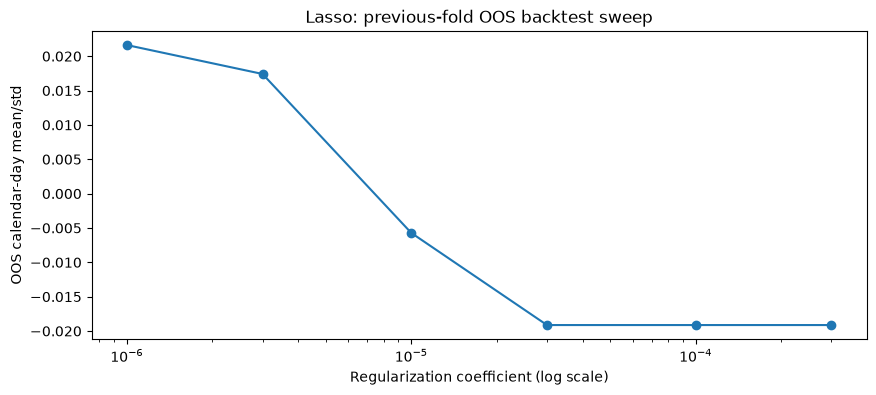

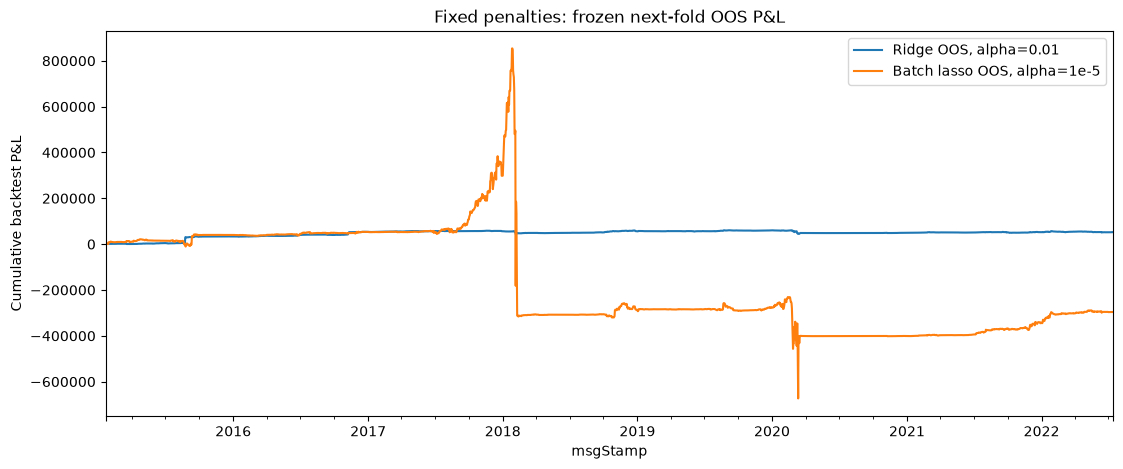

daily_sharpe  pnl_observations       n     slope  \
model alpha                                                          
Ridge 0.000001        0.026734            517761  517761  0.030170   
      0.000010        0.027038            517761  517761  0.032591   
      0.000100        0.027576            517761  517761  0.034544   
      0.001000        0.027922            517761  517761  0.036413   
      0.010000        0.031859            517761  517761  0.039117   
      0.100000        0.032997            517761  517761  0.051886   
      1.000000        0.020008            517761  517761  0.109048   
      10.000000       0.001810            517761  517761  0.368030   
      100.000000     -0.002306            517761  517761  1.178540   
Lasso 0.000001        0.021624            517761  517761  0.032594   
      0.000003        0.017414            517761  517761  0.034820   
      0.000010       -0.005718            517761  517761  0.020083   
      0.000030       -0.019128            517761  517761  0.032443   
      0.000100       -0.019128            517761  517761  0.174894   
      0.000300       -0.019128            517761  517761 -0.279334   

                     intercept  correlation      rmse  zero_forecast_rmse  
model alpha                                                                
Ridge 0.000001    2.051362e-06     0.007241  0.000721            0.000702  
      0.000010    2.047948e-06     0.007714  0.000720            0.000702  
      0.000100    2.045415e-06     0.007938  0.000719            0.000702  
      0.001000    2.044950e-06     0.008069  0.000718            0.000702  
      0.010000    2.037677e-06     0.007880  0.000715            0.000702  
      0.100000    1.990458e-06     0.007508  0.000709            0.000702  
      1.000000    1.852897e-06     0.009189  0.000704            0.000702  
      10.000000   1.283358e-06     0.013394  0.000702            0.000702  
      100.000000 -5.467523e-07     0.012001  0.000702            0.000702  
Lasso 0.000001    2.038398e-06     0.006675  0.000716            0.000702  
      0.000003    2.030947e-06     0.006298  0.000713            0.000702  
      0.000010    2.060251e-06     0.002540  0.000708            0.000702  
      0.000030    2.036838e-06     0.002620  0.000704            0.000702  
      0.000100    1.739053e-06     0.006805  0.000703            0.000702  
      0.000300    2.734405e-06    -0.001648  0.000702            0.000702

BATCH_OOS_SWEEP
                  daily_sharpe  pnl_observations       n     slope     intercept  correlation      rmse  zero_forecast_rmse
model alpha                                                                                                                
Ridge 0.000001        0.026734            517761  517761  0.030170  2.051362e-06     0.007241  0.000721            0.000702
      0.000010        0.027038            517761  517761  0.032591  2.047948e-06     0.007714  0.000720            0.000702
      0.000100        0.027576            517761  517761  0.034544  2.045415e-06     0.007938  0.000719            0.000702
      0.001000        0.027922            517761  517761  0.036413  2.044950e-06     0.008069  0.000718            0.000702
      0.010000        0.031859            517761  517761  0.039117  2.037677e-06     0.007880  0.000715            0.000702
      0.100000        0.032997            517761  517761  0.051886  1.990458e-06     0.007508  0.000709            0

In [24]:
models = {f'Ridge {a:g}': BatchRidge(len(fit_columns), alpha=float(a), decay=DECAY) for a in RIDGE_ALPHAS}
models.update({f'Lasso {a:g}': BatchLasso(len(fit_columns), DECAY, float(a),
                                      fit_intercept=True, tol=1e-11) for a in LASSO_ALPHAS})
started = perf_counter()
batch_paths = walk_forward_sweep(models, X_fit, y_fit, W=W_fit, **FOLD)
batch_seconds = perf_counter()-started
batch_daily, batch_rows = {}, []
for name, path in batch_paths.items():
    daily, stats = score_prediction(oos_series(path.prediction_))
    batch_daily[name] = daily
    batch_rows.append(dict(model=name.split()[0], alpha=models[name].alpha, **stats))
batch_sweep = pd.DataFrame(batch_rows).set_index(['model','alpha'])
for family in ['Ridge', 'Lasso']:
    batch_sweep.loc[family, 'daily_sharpe'].plot(logx=True, marker='o', figsize=(10,4),
        title=f'{family}: previous-fold OOS backtest sweep')
    plt.xlabel('Regularization coefficient (log scale)'); plt.ylabel('OOS calendar-day mean/std')
    plt.show(); plt.close('all')
fixed_batch = pd.DataFrame({
    'Ridge OOS, alpha=0.01': batch_daily[f'Ridge {RIDGE_ALPHA:g}'],
    'Batch lasso OOS, alpha=1e-5': batch_daily[f'Lasso {DEFAULT_ALPHA:g}'],
})
fixed_batch.cumsum().plot(figsize=(13,5),title='Fixed penalties: frozen next-fold OOS P&L')
plt.ylabel('Cumulative backtest P&L'); plt.show(); plt.close('all')
display(batch_sweep)
print('BATCH_OOS_SWEEP'); print(batch_sweep.to_string()); print('Batch grid seconds:',batch_seconds)


## Streaming lasso: live updates versus frozen checkpoint fits

For each alpha, replay all rows once. `live` predicts before every row update. `frozen` takes the very same estimator's coefficients at the batch cutoffs and holds them until the next fold. This separates **update frequency** from **implementation correctness**: compare batch with frozen streaming first, then compare frozen with live streaming.

The main history is retained at fixed alpha=1e-5. Solver tolerance is tightened to 1e-10 with 20,000 sweeps; failed updates are counted, not suppressed. Only requested audit checkpoints retain moment snapshots.

/home/runner/work/th/th/src/takehome/fitters.py:582: RuntimeWarning: 15 updates did not converge; inspect KKT errors or raise max_iter.
  live[last:stop] = model.fit_predict(X[last:stop], y[last:stop], W=w[last:stop])


/home/runner/work/th/th/src/takehome/fitters.py:582: RuntimeWarning: 12 updates did not converge; inspect KKT errors or raise max_iter.
  live[last:stop] = model.fit_predict(X[last:stop], y[last:stop], W=w[last:stop])


/home/runner/work/th/th/src/takehome/fitters.py:582: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  live[last:stop] = model.fit_predict(X[last:stop], y[last:stop], W=w[last:stop])


ONLINE alpha=1e-06: 452.81s; failed updates=42


/home/runner/work/th/th/src/takehome/fitters.py:590: RuntimeWarning: 14 updates did not converge; inspect KKT errors or raise max_iter.
  live[last:] = model.fit_predict(X[last:], y[last:], W=w[last:])


...

ONLINE alpha=3e-06: 141.02s; failed updates=1


ONLINE alpha=1e-05: 45.28s; failed updates=0


ONLINE alpha=3e-05: 30.82s; failed updates=0


ONLINE alpha=0.0001: 29.67s; failed updates=0


ONLINE alpha=0.0003: 29.62s; failed updates=0


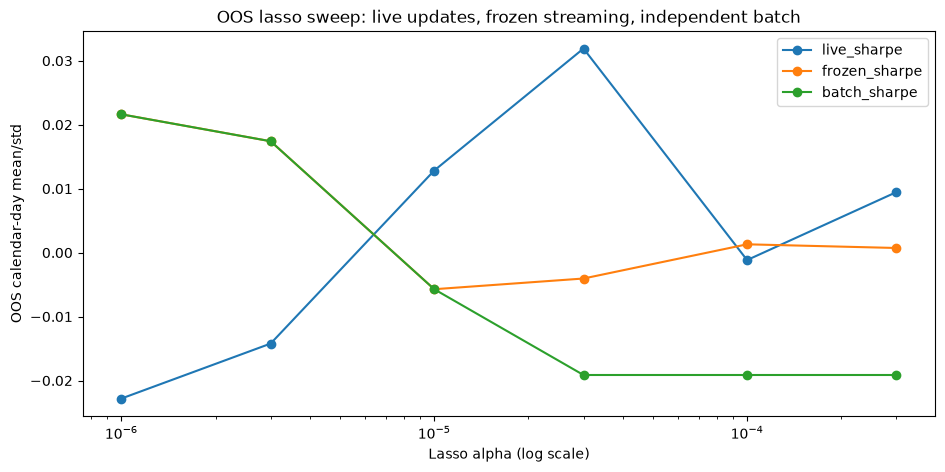

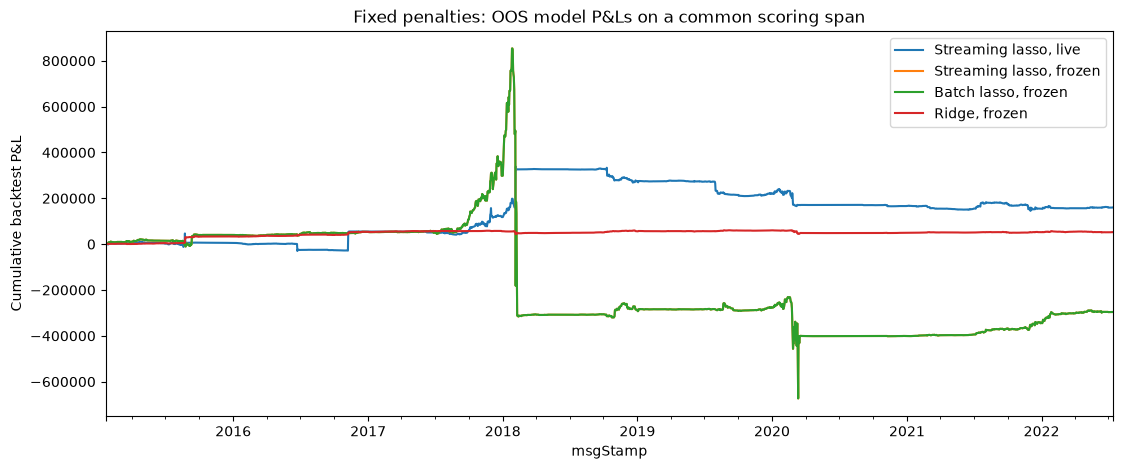

,live_sharpe,frozen_sharpe,batch_sharpe,frozen_prediction_rmse,frozen_max_abs_error,failed_updates,final_KKT,seconds,slope,correlation
alpha,,,,,,,,,,
0.000001,-0.022811,0.021626,0.021624,2.308244e-09,2.024885e-07,42,9.917691e-11,452.813215,-0.042559,-0.006684
0.000003,-0.014215,0.017415,0.017414,1.028580e-09,9.344542e-08,1,9.944028e-11,141.017928,-0.073303,-0.009507
0.000010,0.012838,-0.005718,-0.005718,3.794981e-10,2.194624e-08,0,9.364073e-11,45.278349,-0.156297,-0.014102
0.000030,0.031907,-0.004046,-0.019128,1.057825e-10,8.498930e-09,0,0.000000e+00,30.824106,-0.238831,-0.013218
0.000100,-0.001161,0.001303,-0.019128,9.060311e-11,8.937868e-09,0,0.000000e+00,29.671531,0.254108,0.005981
0.000300,0.009462,0.000727,-0.019128,4.811038e-15,2.944374e-13,0,0.000000e+00,29.617867,-0.843204,-0.004881


STREAMING_VS_BATCH
          live_sharpe  frozen_sharpe  batch_sharpe  frozen_prediction_rmse  frozen_max_abs_error  failed_updates     final_KKT     seconds     slope  correlation
alpha                                                                                                                                                            
0.000001    -0.022811       0.021626      0.021624            2.308244e-09          2.024885e-07              42  9.917691e-11  452.813215 -0.042559    -0.006684
0.000003    -0.014215       0.017415      0.017414            1.028580e-09          9.344542e-08               1  9.944028e-11  141.017928 -0.073303    -0.009507
0.000010     0.012838      -0.005718     -0.005718            3.794981e-10          2.194624e-08               0  9.364073e-11   45.278349 -0.156297    -0.014102
0.000030     0.031907      -0.004046     -0.019128            1.057825e-10          8.498930e-09               0  0.000000e+00   30.824106 -0.238831    -0.013218
0.000100 

In [25]:
online_results, online_rows, stream_daily = {}, [], {}
audit_ids = np.unique(np.linspace(0, len(folds)-1, 6, dtype=int)).tolist()
for alpha in LASSO_ALPHAS:
    m = StreamingWeightedLasso(len(fit_columns), DECAY, float(alpha), max_iter=20000, tol=1e-10,
                              fit_intercept=True, store_history=True if alpha==DEFAULT_ALPHA else False)
    started = perf_counter()
    result = stream_at_folds(m, X_fit, y_fit, folds, W=W_fit,
                            audit_folds=audit_ids if alpha==DEFAULT_ALPHA else ())
    seconds = perf_counter()-started
    live_daily, live_stats = score_prediction(oos_series(result['live']))
    frozen_daily, frozen_stats = score_prediction(oos_series(result['frozen']))
    reference = batch_paths[f'Lasso {alpha:g}'].prediction_
    difference = result['frozen']-reference
    online_rows.append(dict(alpha=alpha, live_sharpe=live_stats['daily_sharpe'],
        frozen_sharpe=frozen_stats['daily_sharpe'],
        batch_sharpe=batch_sweep.loc[('Lasso',alpha),'daily_sharpe'],
        frozen_prediction_rmse=np.sqrt(np.nanmean(difference**2)),
        frozen_max_abs_error=np.nanmax(abs(difference)),
        failed_updates=m.n_failed_, final_KKT=m.kkt_violation_, seconds=seconds,
        slope=live_stats['slope'], correlation=live_stats['correlation']))
    online_results[float(alpha)] = result
    stream_daily[float(alpha)] = live_daily
    if alpha==DEFAULT_ALPHA:
        fitter, online_yhat, default_result = m, pd.Series(result['live'], index=df.index), result
        default_live_daily, default_frozen_daily = live_daily, frozen_daily
    print(f'ONLINE alpha={alpha:g}: {seconds:.2f}s; failed updates={m.n_failed_}', flush=True)
online_sweep = pd.DataFrame(online_rows).set_index('alpha')
online_sweep[['live_sharpe','frozen_sharpe','batch_sharpe']].plot(
    logx=True,marker='o',figsize=(11,5),title='OOS lasso sweep: live updates, frozen streaming, independent batch')
plt.xlabel('Lasso alpha (log scale)'); plt.ylabel('OOS calendar-day mean/std')
plt.show(); plt.close('all')
comparison_daily = pd.DataFrame({
    'Streaming lasso, live': default_live_daily,
    'Streaming lasso, frozen': default_frozen_daily,
    'Batch lasso, frozen': batch_daily[f'Lasso {DEFAULT_ALPHA:g}'],
    'Ridge, frozen': batch_daily[f'Ridge {RIDGE_ALPHA:g}'],
})
comparison_daily.cumsum().plot(figsize=(13,5),title='Fixed penalties: OOS model P&Ls on a common scoring span')
plt.ylabel('Cumulative backtest P&L'); plt.show(); plt.close('all')
display(online_sweep)
print('STREAMING_VS_BATCH'); print(online_sweep.to_string())
print('FIXED_OOS_SHARPES'); print(comparison_daily.pipe(sharpe).to_string())


### Investigating a performance gap

Compare the frozen prediction vectors, not just Sharpe. At selected identical full-history cutoffs, compare weighted means, standardized covariance/cross-moments and original-unit loss. Then repeat the row-residual CVXPY reference on real 4,096-row windows. This tests the actual feature scales, imputation and returns rather than relying only on synthetic arrays.

The zero-filled design, W=1, decay, intercept, penalty, warm-up and test timestamps are identical in the frozen comparison. Coefficients may be non-unique for redundant predictors, so prediction and objective agreement are more informative than raw coefficient differences. A live-versus-frozen gap can instead reflect refitting frequency or estimation noise. The inverse-variance backtest can also amplify very small numerical differences when forecast variance is near zero; the shared-denominator comparison below tests that separately.

In [26]:
audit_rows = []
reference_path = batch_paths[f'Lasso {DEFAULT_ALPHA:g}']
for i in audit_ids:
    stop = folds[i]['train_stop']
    moments = batch_moments(X_fit[:stop], y_fit[:stop], W_fit[:stop], DECAY)
    G, h, scale, v = _scaled_moments(moments, True)
    state = default_result['states'][i]
    theta = default_result['coefs'][i]*scale
    objective = .5*(v-2*h@theta+theta@G@theta)+DEFAULT_ALPHA*abs(theta).sum()
    audit_rows.append(dict(fold=i, training_stop=stop,
        max_scaled_mean_error=np.max(abs(state[0]-moments[0])/scale),
        max_standardized_cov_error=np.max(abs(state[2]-moments[2])/scale[:,None]/scale),
        max_scaled_cross_error=np.max(abs(state[3]-moments[3])/scale),
        objective_gap=abs(objective-reference_path.objectives_[i]),
        streaming_KKT=default_result['kkt_at_folds'][i]))
implementation_audit = pd.DataFrame(audit_rows)
display(implementation_audit)
print('FULL_PREFIX_AUDIT'); print(implementation_audit.to_string(index=False))

real_checks=[]
for stop in [folds[0]['train_stop'], folds[len(folds)//2]['train_stop'], len(df)]:
    start=max(0,stop-4096)
    xx, yy, ww=X_fit[start:stop], y_fit[start:stop], W_fit[start:stop]
    direct=CvxpyWeightedLasso(len(fit_columns),DECAY,DEFAULT_ALPHA,fit_intercept=True,tol=1e-12).fit(xx,yy,W=ww)
    compiled=StreamingWeightedLasso(len(fit_columns),DECAY,DEFAULT_ALPHA,fit_intercept=True,
                                  tol=1e-11,max_iter=50000).fit(xx,yy,W=ww)
    fast_batch=BatchLasso(len(fit_columns),DECAY,DEFAULT_ALPHA,fit_intercept=True,tol=1e-12).fit(xx,yy,W=ww)
    real_checks.append(dict(training_stop=stop, rows=stop-start,
        stream_vs_row_cvxpy_max_error=np.max(abs(compiled.predict(xx)-direct.predict(xx))),
        batch_vs_row_cvxpy_max_error=np.max(abs(fast_batch.predict(xx)-direct.predict(xx))),
        final_stream_KKT=compiled.kkt_violation_, final_converged=compiled.converged_))
real_checks=pd.DataFrame(real_checks); display(real_checks)
print('REAL_ROW_CVXPY_CHECKS'); print(real_checks.to_string(index=False))

# Strictly solve the SAME moments without appending another observation.
from takehome.fitters import _coordinate_descent
worst=int(implementation_audit.loc[implementation_audit.objective_gap.idxmax(),'fold'])
stop=folds[worst]['train_stop']; a,b=folds[worst]['predict_start'],folds[worst]['predict_stop']
strict_moments=batch_moments(X_fit[:stop],y_fit[:stop],W_fit[:stop],DECAY)
G,h,scale,v=_scaled_moments(strict_moments,True)
theta=default_result['coefs'][worst]*scale
iterations,kkt,tolerance=_coordinate_descent(G,h,theta,DEFAULT_ALPHA,500000,1e-13)
mx,my=strict_moments[:2]
strict_prediction=X_fit[a:b]@(theta/scale)+(my-mx@(theta/scale))
strict_check=pd.Series(dict(fold=worst, strict_iterations=iterations, strict_KKT=kkt,
    max_next_fold_error=np.max(abs(strict_prediction-reference_path.prediction_[a:b]))))
display(strict_check.to_frame('same_objective_strict_solve'))
print('STRICT_CHECK'); print(strict_check.to_string())

ref=oos_series(reference_path.prediction_)
frozen=oos_series(default_result['frozen'])
shared_scale=ts_std(ref,HL).pow(2).replace(0,np.nan)
shared_pnl=pd.concat({'Batch':ref.div(shared_scale).mul(df.ret_5m),
                     'Frozen stream':frozen.div(shared_scale).mul(df.ret_5m)},axis=1)
shared_daily=shared_pnl.where(pd.Series(rows>=SCORE_FIRST,index=df.index),axis=0).resample('D').sum().loc[score_day:]
print('SHARED_DENOMINATOR_SHARPES'); print(shared_daily.pipe(sharpe).to_string())
relative_prediction_error=online_sweep.loc[DEFAULT_ALPHA,'frozen_prediction_rmse']/df.ret_5m.std()
print('Frozen prediction RMSE / target standard deviation:',relative_prediction_error)
print('Numerical agreement and refit-frequency effects must be assessed separately; inspect the diagnostics above.')


,fold,training_stop,max_scaled_mean_error,max_standardized_cov_error,max_scaled_cross_error,objective_gap,streaming_KKT
0,0,72576,6.187555e-16,1.197348e-14,1.298277e-19,4.314574e-21,9.346902e-11
1,18,181440,4.806861e-16,2.078284e-14,9.658296e-20,4.480010e-20,0.000000e+00
2,37,296352,1.530564e-15,1.555771e-14,6.751702e-20,1.373120e-20,0.000000e+00
3,55,405216,1.060887e-15,1.233427e-14,8.994921e-20,2.774033e-19,0.000000e+00
4,74,520128,8.277154e-16,1.664859e-14,1.543663e-19,4.642799e-20,2.101571e-11
5,93,635040,5.067118e-16,1.541755e-14,2.244994e-19,7.618003e-19,9.533835e-11


FULL_PREFIX_AUDIT
 fold  training_stop  max_scaled_mean_error  max_standardized_cov_error  max_scaled_cross_error  objective_gap  streaming_KKT
    0          72576           6.187555e-16                1.197348e-14            1.298277e-19   4.314574e-21   9.346902e-11
   18         181440           4.806861e-16                2.078284e-14            9.658296e-20   4.480010e-20   0.000000e+00
   37         296352           1.530564e-15                1.555771e-14            6.751702e-20   1.373120e-20   0.000000e+00
   55         405216           1.060887e-15                1.233427e-14            8.994921e-20   2.774033e-19   0.000000e+00
   74         520128           8.277154e-16                1.664859e-14            1.543663e-19   4.642799e-20   2.101571e-11
   93         635040           5.067118e-16                1.541755e-14            2.244994e-19   7.618003e-19   9.533835e-11


,training_stop,rows,stream_vs_row_cvxpy_max_error,batch_vs_row_cvxpy_max_error,final_stream_KKT,final_converged
0,72576,4096,5.257945e-10,2.860666e-15,9.937883e-12,True
1,356832,4096,2.166701e-14,1.196109e-14,0.000000e+00,True
2,640734,4096,2.664455e-10,3.052286e-11,9.813939e-12,True


REAL_ROW_CVXPY_CHECKS
 training_stop  rows  stream_vs_row_cvxpy_max_error  batch_vs_row_cvxpy_max_error  final_stream_KKT  final_converged
         72576  4096                   5.257945e-10                  2.860666e-15      9.937883e-12             True
        356832  4096                   2.166701e-14                  1.196109e-14      0.000000e+00             True
        640734  4096                   2.664455e-10                  3.052286e-11      9.813939e-12             True


,same_objective_strict_solve
fold,9.300000e+01
strict_iterations,6.300000e+01
strict_KKT,9.550255e-14
max_next_fold_error,9.759708e-11


STRICT_CHECK
fold                   9.300000e+01
strict_iterations      6.300000e+01
strict_KKT             9.550255e-14
max_next_fold_error    9.759708e-11
SHARED_DENOMINATOR_SHARPES
Batch           -0.005718
Frozen stream   -0.005718
Frozen prediction RMSE / target standard deviation: 5.612614923576166e-07
Numerical agreement and refit-frequency effects must be assessed separately; inspect the diagnostics above.


## Coefficient paths and lagged OOS calibration

The coefficient chart shows the post-update history of the default unit-weight lasso. The scatter uses the **common OOS scoring span**, not the initial fitting period. Both coefficients and intercept are shifted by one row. Calibration is y on yhat, with an intercept, and is not used to rescale predictions.

In [27]:
beta = pd.DataFrame(fitter.get_coefs(), index=df.index, columns=fit_columns)
intercept = pd.Series(fitter.get_intercepts(), index=df.index, name='intercept')
# Post-update coefficients include y_t: shift BOTH coefficients and intercept.
yhat = beta.shift().mul(df[fit_columns].replace([np.inf, -np.inf], np.nan).fillna(0)).sum(axis=1, min_count=len(fit_columns))
yhat = yhat.add(intercept.shift()).rename('yhat')
prior_updates = pd.Series(valid_fit, index=df.index).cumsum().shift(fill_value=0)
yhat = yhat.where(prior_updates.gt(0))

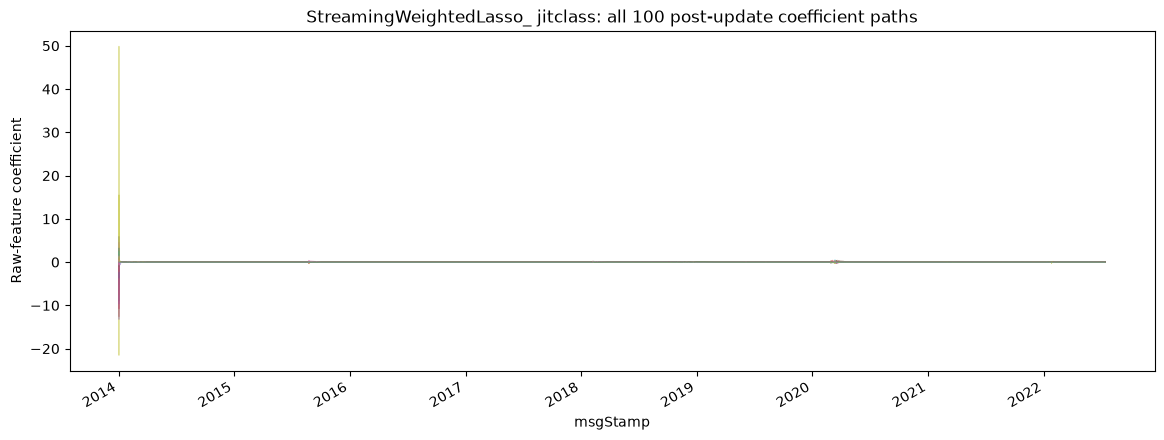

In [28]:
np.testing.assert_allclose(yhat, online_yhat, rtol=1e-9, atol=1e-10, equal_nan=True)
beta.plot(figsize=(14,5),legend=False,linewidth=.6,alpha=.5,
          title='StreamingWeightedLasso_ jitclass: all 100 post-update coefficient paths')
plt.ylabel('Raw-feature coefficient'); plt.show(); plt.close('all')


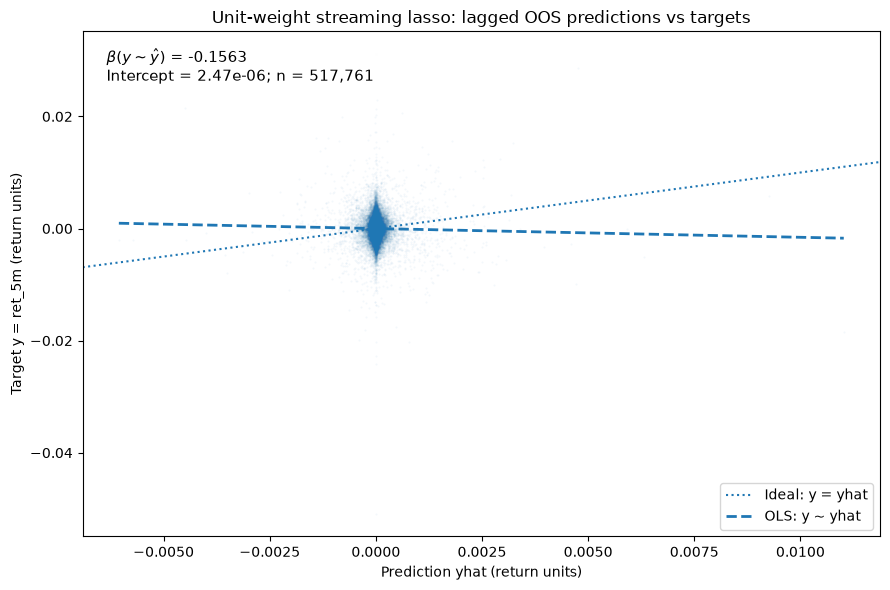

,n,slope,intercept,r_squared
OLS,517761,-0.156297,0.000002,0.000199


OOS_CALIBRATION
          n     slope  intercept  r_squared
OLS  517761 -0.156297   0.000002   0.000199


In [29]:
calibration=plot_calibration(yhat.where(rows>=SCORE_FIRST),df.ret_5m,
    title='Unit-weight streaming lasso: lagged OOS predictions vs targets')
display(calibration)
print('OOS_CALIBRATION'); print(calibration.to_string())


# Optimistic future-predictor diagnostic

For h=1,2,6,12,24, feed `df[x_cols].shift(-h)` into the unchanged `evaluate_features` workflow. Include h=0 as the control. These are **intentionally look-ahead oracle features**, not tradable signals and not a measured AR(1) forecast. Knowing a realized future feature may include information from the target's return interval. This is an optimistic experiment, not a mathematical upper bound for every feasible forecasting/position-sizing rule.

Shift only the already-reserved training frame: the trailing h rows become missing, and no values are pulled from the test block. All horizons exclude the last 24 target rows for a common endpoint. Feature missingness still differs by horizon and is reported. Leads count dataframe rows, not elapsed minutes across gaps. Each horizon gets its own P&L plot, Sharpe histogram and lagged EWM-Sharpe combination; the combination remains on the secondary axis. The meta estimator itself sees only its past oracle P&L, but the underlying signal is deliberately noncausal.

## Predictor lead h=0 — causal-input control

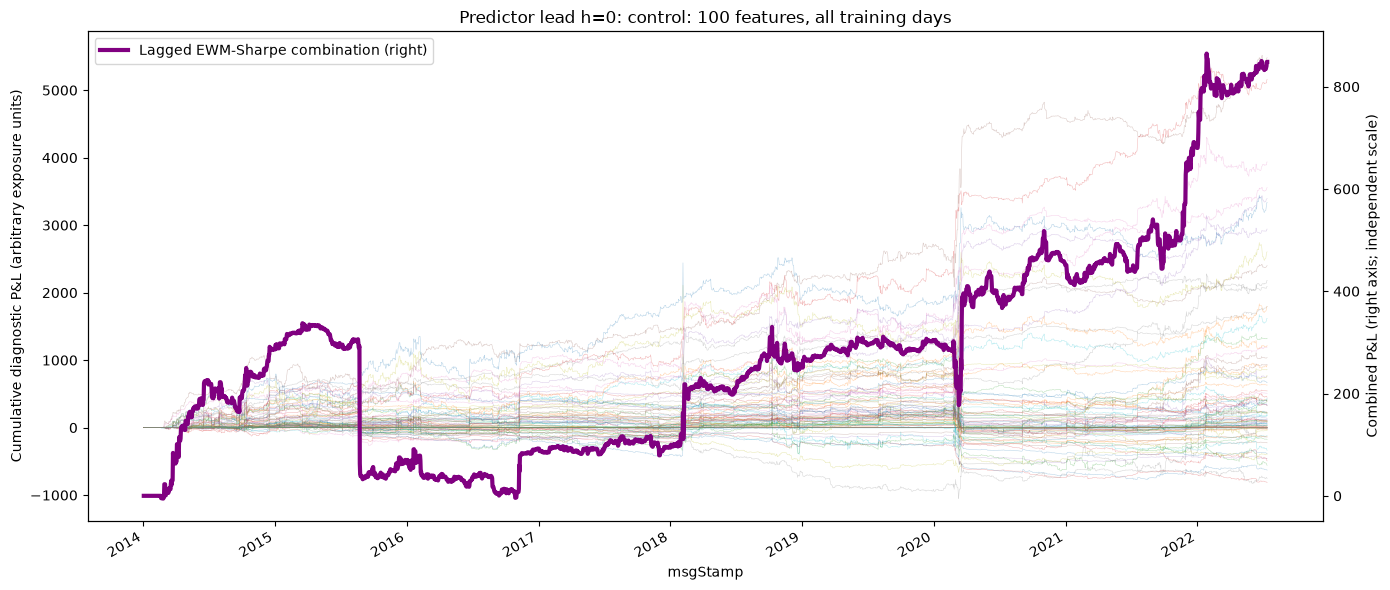

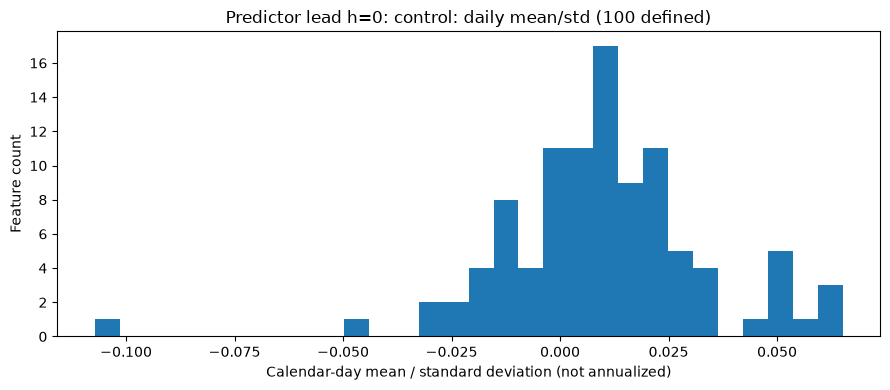

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x94,0.065095,153523,2064,2014-04-29 12:15:00-04:00,2022-07-13 16:00:00-04:00
x76,0.063963,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x77,0.060185,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x86,0.055775,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x78,0.053404,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x85,0.051261,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x58,0.051148,332732,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x97,0.051007,147767,2058,2014-05-07 11:50:00-04:00,2022-07-13 16:00:00-04:00
x87,0.048338,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x95,0.047486,153523,2064,2014-04-29 12:15:00-04:00,2022-07-13 16:00:00-04:00


In [30]:
h = 0
oracle_returns = df.ret_5m.where(rows < len(df)-24)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


## Predictor lead h=1 — LOOK-AHEAD

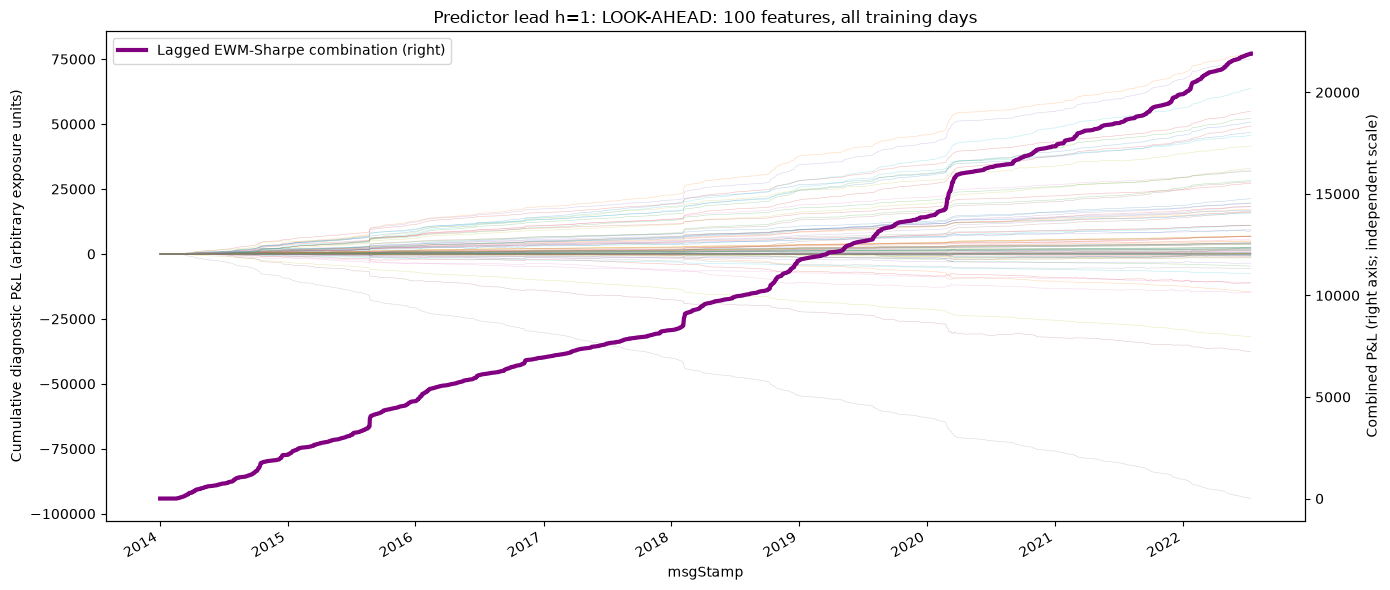

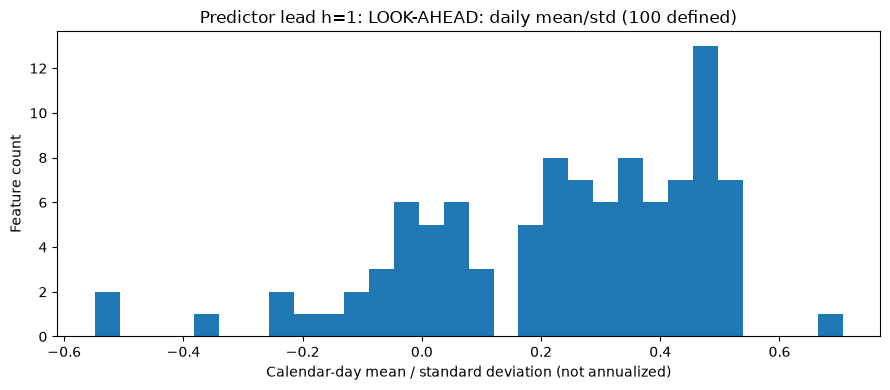

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x100,0.705870,578324,2620,2014-02-03 09:30:00-05:00,2022-07-13 22:30:00-04:00
x55,0.534492,472758,2579,2014-03-06 14:10:00-05:00,2022-07-13 22:30:00-04:00
x4,0.531801,323780,2111,2014-02-26 12:00:00-05:00,2022-07-13 15:55:00-04:00
x1,0.529946,327822,2130,2014-02-26 12:00:00-05:00,2022-07-13 15:55:00-04:00
x7,0.521906,338779,1692,2017-02-05 21:55:00-05:00,2022-07-13 22:30:00-04:00
x61,0.500905,162890,2121,2014-04-23 15:25:00-04:00,2022-07-13 15:55:00-04:00
x13,0.499781,146339,1372,2017-03-22 12:55:00-04:00,2022-07-13 15:55:00-04:00
x43,0.499630,162888,2121,2014-04-23 15:25:00-04:00,2022-07-13 15:55:00-04:00
x16,0.495667,146339,1372,2017-03-22 12:55:00-04:00,2022-07-13 15:55:00-04:00
x40,0.495488,438633,2502,2014-02-19 05:35:00-05:00,2022-07-13 22:30:00-04:00


In [31]:
h = 1
oracle_returns = df.ret_5m.where(rows < len(df)-24)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


## Predictor lead h=2 — LOOK-AHEAD

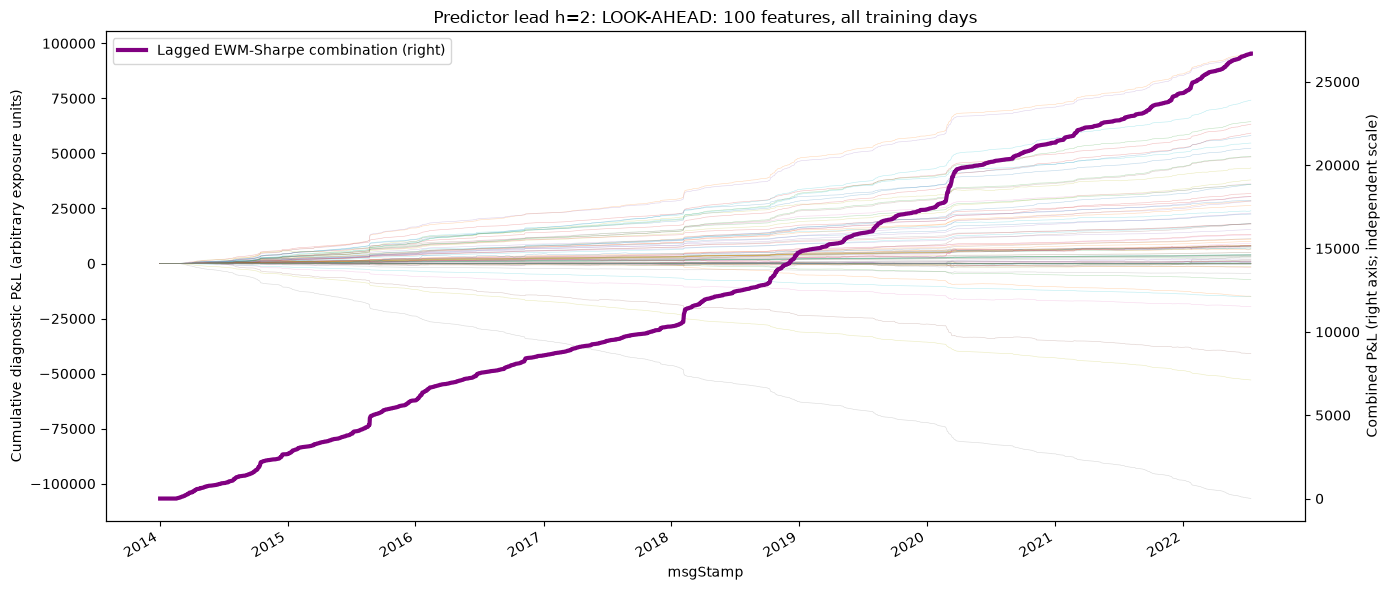

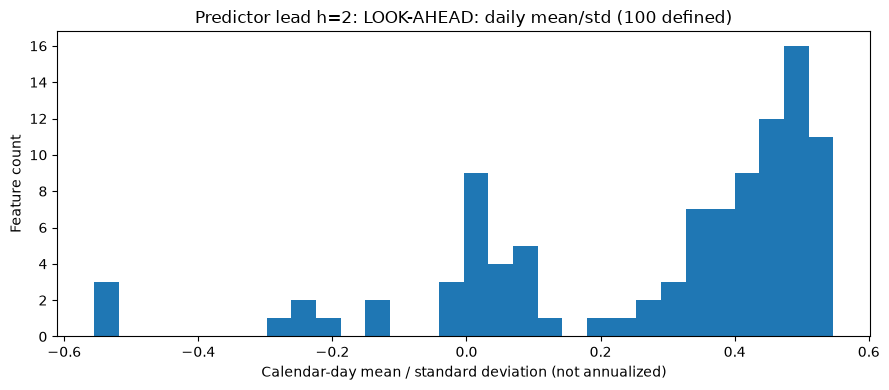

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x55,0.547250,470863,2579,2014-03-06 14:10:00-05:00,2022-07-13 22:30:00-04:00
x1,0.544979,327816,2130,2014-02-26 12:00:00-05:00,2022-07-13 15:50:00-04:00
x5,0.541795,323774,2111,2014-02-26 12:00:00-05:00,2022-07-13 15:50:00-04:00
x2,0.539412,327816,2130,2014-02-26 12:00:00-05:00,2022-07-13 15:50:00-04:00
x4,0.537408,323774,2111,2014-02-26 12:00:00-05:00,2022-07-13 15:50:00-04:00
x7,0.529025,337369,1692,2017-02-05 21:50:00-05:00,2022-07-13 22:30:00-04:00
x37,0.528447,162772,2121,2014-04-23 15:30:00-04:00,2022-07-13 15:50:00-04:00
x56,0.523140,470863,2579,2014-03-06 14:10:00-05:00,2022-07-13 22:30:00-04:00
x61,0.519745,162886,2121,2014-04-23 15:20:00-04:00,2022-07-13 15:50:00-04:00
x38,0.513867,162772,2121,2014-04-23 15:30:00-04:00,2022-07-13 15:50:00-04:00


In [32]:
h = 2
oracle_returns = df.ret_5m.where(rows < len(df)-24)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


## Predictor lead h=6 — LOOK-AHEAD

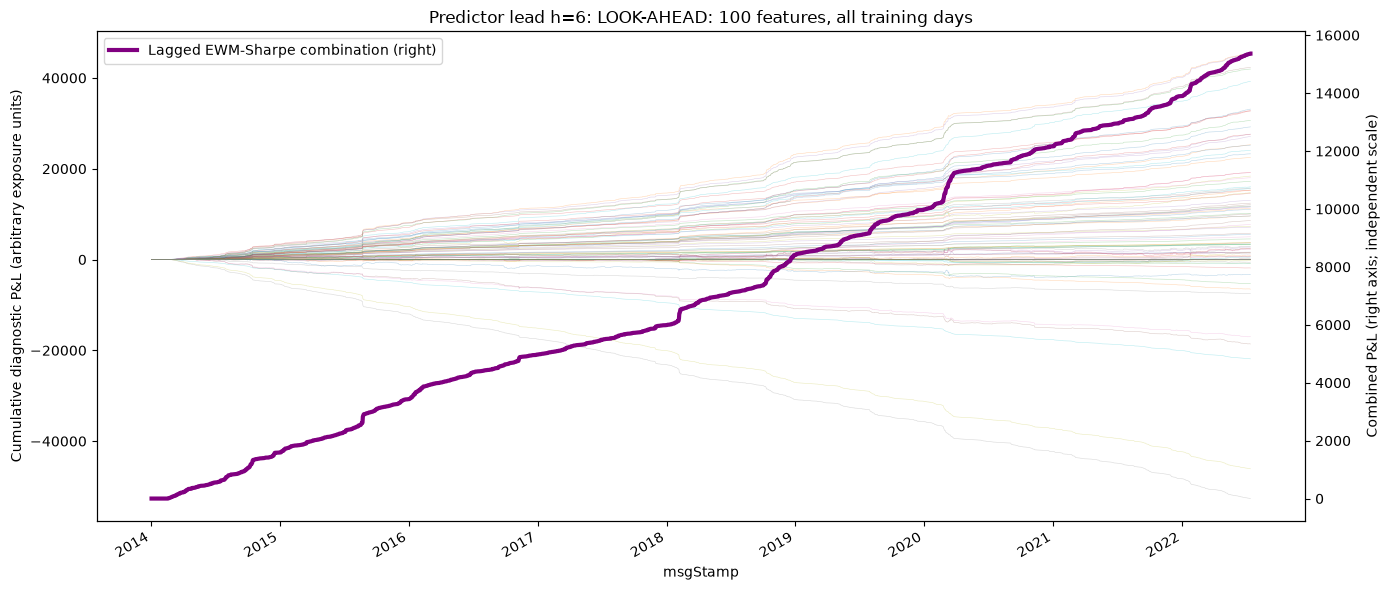

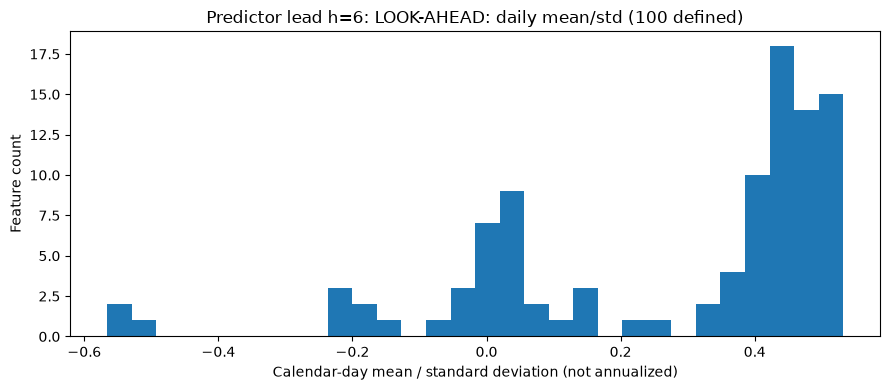

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x6,0.531970,323758,2111,2014-02-26 12:00:00-05:00,2022-07-13 15:30:00-04:00
x3,0.527811,327800,2130,2014-02-26 12:00:00-05:00,2022-07-13 15:30:00-04:00
x56,0.524839,470975,2579,2014-03-06 14:05:00-05:00,2022-07-13 22:30:00-04:00
x63,0.524061,162878,2121,2014-04-23 15:00:00-04:00,2022-07-13 15:30:00-04:00
x2,0.516143,327800,2130,2014-02-26 12:00:00-05:00,2022-07-13 15:30:00-04:00
x55,0.515709,470975,2579,2014-03-06 14:05:00-05:00,2022-07-13 22:30:00-04:00
x61,0.515295,162878,2121,2014-04-23 15:00:00-04:00,2022-07-13 15:30:00-04:00
x57,0.510160,470975,2579,2014-03-06 14:05:00-05:00,2022-07-13 22:30:00-04:00
x5,0.509987,323758,2111,2014-02-26 12:00:00-05:00,2022-07-13 15:30:00-04:00
x45,0.508105,162876,2121,2014-04-23 15:00:00-04:00,2022-07-13 15:30:00-04:00


In [33]:
h = 6
oracle_returns = df.ret_5m.where(rows < len(df)-24)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


## Predictor lead h=12 — LOOK-AHEAD

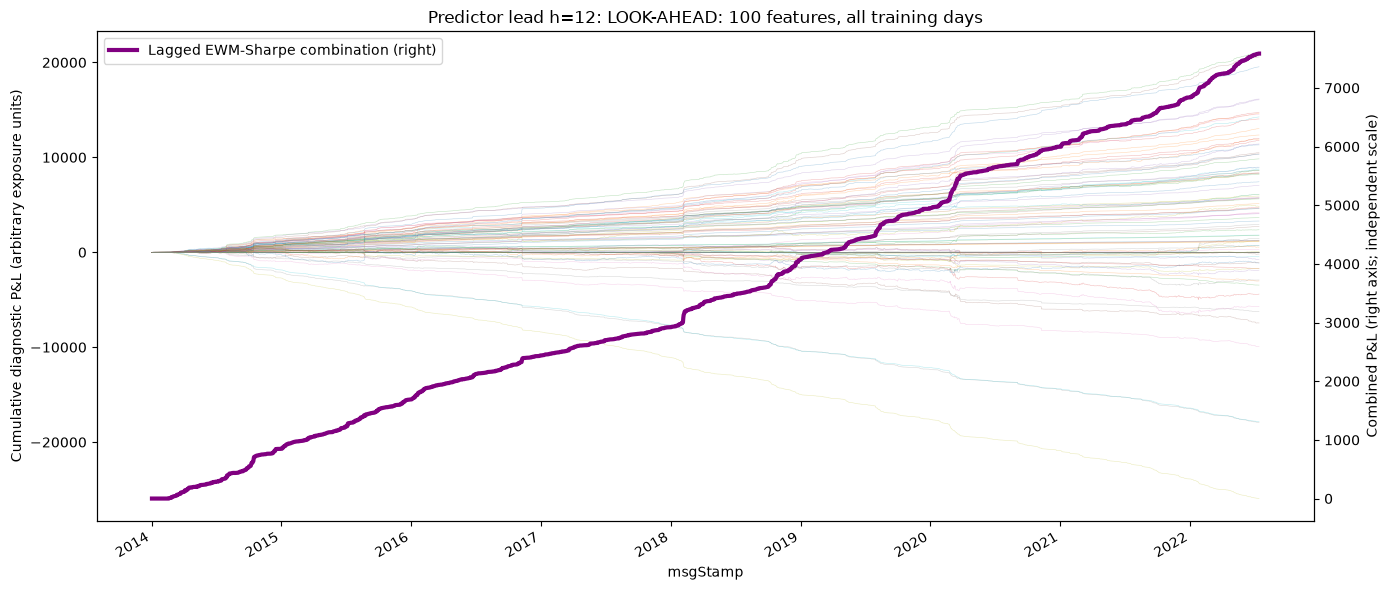

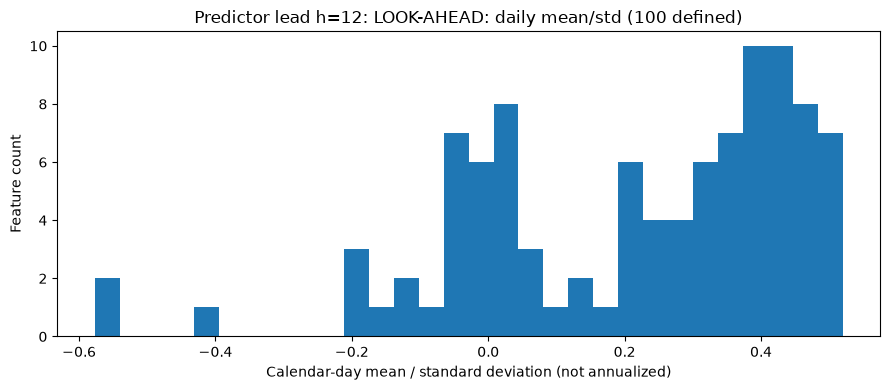

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x3,0.519631,327788,2130,2014-02-26 12:00:00-05:00,2022-07-13 15:00:00-04:00
x63,0.516548,162878,2121,2014-04-23 14:30:00-04:00,2022-07-13 15:00:00-04:00
x6,0.512815,323746,2111,2014-02-26 12:00:00-05:00,2022-07-13 15:00:00-04:00
x45,0.500112,162876,2121,2014-04-23 14:30:00-04:00,2022-07-13 15:00:00-04:00
x2,0.491296,327788,2130,2014-02-26 12:00:00-05:00,2022-07-13 15:00:00-04:00
x62,0.488105,162878,2121,2014-04-23 14:30:00-04:00,2022-07-13 15:00:00-04:00
x39,0.486551,162764,2121,2014-04-23 14:40:00-04:00,2022-07-13 15:00:00-04:00
x44,0.476647,162876,2121,2014-04-23 14:30:00-04:00,2022-07-13 15:00:00-04:00
x5,0.471899,323746,2111,2014-02-26 12:00:00-05:00,2022-07-13 15:00:00-04:00
x57,0.469103,470886,2579,2014-03-06 13:40:00-05:00,2022-07-13 22:30:00-04:00


In [34]:
h = 12
oracle_returns = df.ret_5m.where(rows < len(df)-24)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


## Predictor lead h=24 — LOOK-AHEAD

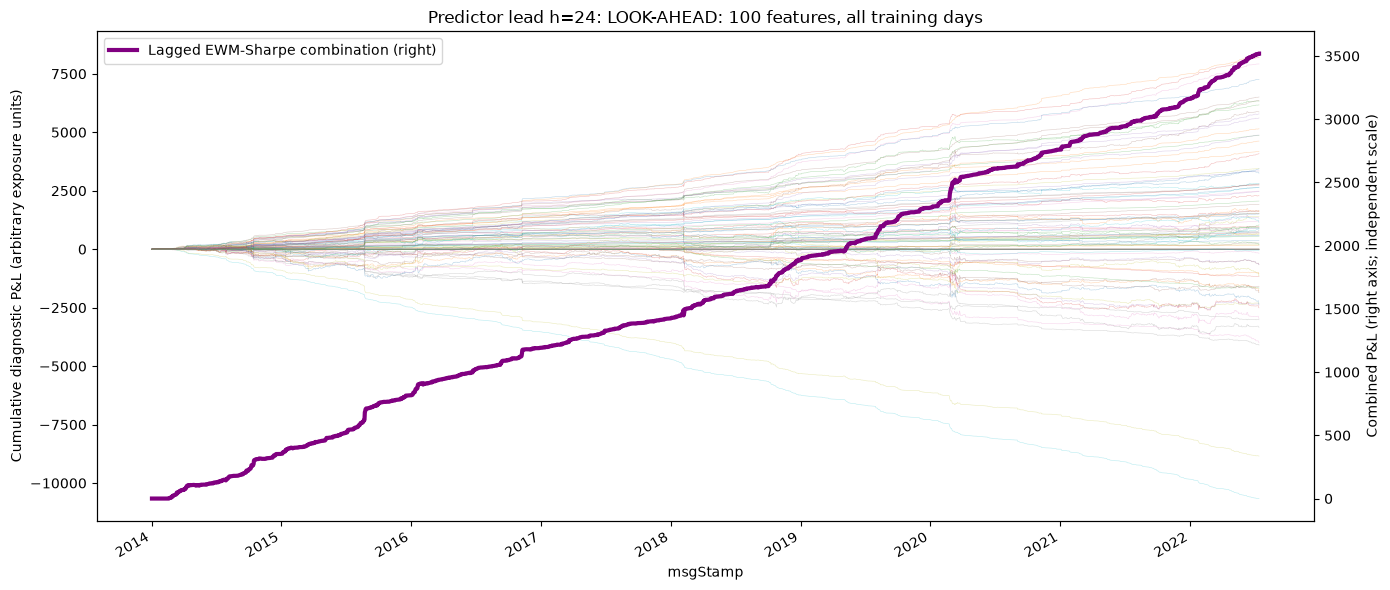

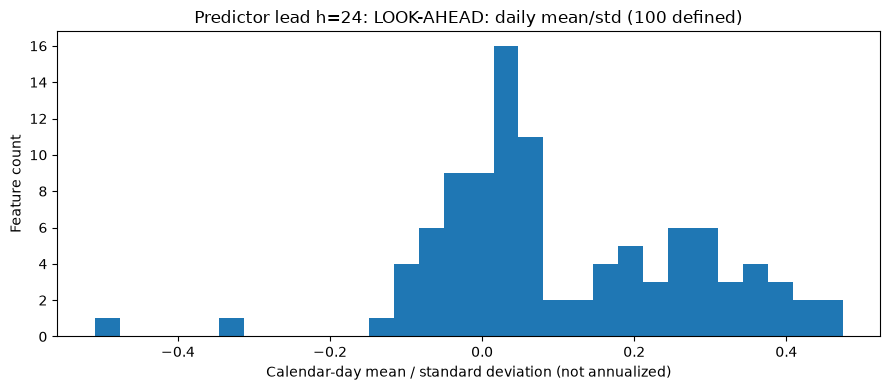

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x3,0.474008,327750,2130,2014-02-26 12:00:00-05:00,2022-07-13 14:00:00-04:00
x6,0.458022,323710,2111,2014-02-26 12:00:00-05:00,2022-07-13 14:00:00-04:00
x63,0.416058,162878,2121,2014-04-23 13:30:00-04:00,2022-07-13 14:00:00-04:00
x57,0.409698,463204,2579,2014-03-06 13:15:00-05:00,2022-07-13 22:30:00-04:00
x39,0.401425,162764,2121,2014-04-23 13:40:00-04:00,2022-07-13 14:00:00-04:00
x45,0.395647,162876,2121,2014-04-23 13:30:00-04:00,2022-07-13 14:00:00-04:00
x42,0.384833,428572,2502,2014-02-19 03:40:00-05:00,2022-07-13 22:30:00-04:00
x51,0.367291,166696,2116,2014-04-22 08:45:00-04:00,2022-07-13 14:15:00-04:00
x54,0.357235,161352,2114,2014-04-24 08:15:00-04:00,2022-07-13 13:55:00-04:00
x33,0.353058,160001,2067,2014-04-24 13:40:00-04:00,2022-07-13 14:00:00-04:00


In [35]:
h = 24
oracle_returns = df.ret_5m.where(rows < len(df)-24)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


In [36]:
oracle_comparison=pd.DataFrame(oracle_records).set_index('h')
per_feature_oracle=pd.DataFrame(oracle_score_columns)
for h in [1,2,6,12,24]:
    delta=per_feature_oracle[h]-per_feature_oracle[0]
    oracle_comparison.loc[h,'median_sharpe_change_vs_h0']=delta.median()
    oracle_comparison.loc[h,'fraction_improved_vs_h0']=delta.gt(0).where(delta.notna()).mean()
display(oracle_comparison)
print('ORACLE_SHIFT_SUMMARY'); print(oracle_comparison.to_string())
assert df.index.max()<split['cutoff'] and fitter.n_seen_==len(df)


,candidates,defined,median_sharpe,p95_sharpe,best_sharpe,meta_sharpe,median_pnl_observations,median_sharpe_change_vs_h0,fraction_improved_vs_h0
h,,,,,,,,,
0,100,100,0.009593,0.051368,0.065095,0.037093,160015.0,NaN,NaN
1,100,100,0.276599,0.501955,0.705870,0.489352,160014.0,0.274821,0.81
2,100,100,0.390694,0.529444,0.547250,0.514271,160011.0,0.387363,0.82
6,100,100,0.412767,0.515730,0.531970,0.519119,160002.0,0.396706,0.79
12,100,100,0.278936,0.488265,0.519631,0.501871,160001.0,0.284936,0.78
24,100,100,0.061208,0.395936,0.474008,0.363121,160001.0,0.058742,0.73


ORACLE_SHIFT_SUMMARY
    candidates  defined  median_sharpe  p95_sharpe  best_sharpe  meta_sharpe  median_pnl_observations  median_sharpe_change_vs_h0  fraction_improved_vs_h0
h                                                                                                                                                         
0          100      100       0.009593    0.051368     0.065095     0.037093                 160015.0                         NaN                      NaN
1          100      100       0.276599    0.501955     0.705870     0.489352                 160014.0                    0.274821                     0.81
2          100      100       0.390694    0.529444     0.547250     0.514271                 160011.0                    0.387363                     0.82
6          100      100       0.412767    0.515730     0.531970     0.519119                 160002.0                    0.396706                     0.79
12         100      100       0.278936    0.48826

# Execution environment

Versions used for this evaluation are shown here, rather than exported to a separate file. The figures and statistical results above remain training-only.

In [37]:
from importlib.metadata import version
import platform

print(f'Python {platform.python_version()}')
packages = ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'pyarrow',
            'diptest', 'numba', 'cvxpy', 'clarabel', 'pandas_market_calendars', 'nbformat', 'nbclient', 'ipykernel']
display(pd.Series({p: version(p) for p in packages}, name='version').to_frame())

Python 3.11.16


,version
numpy,2.4.6
pandas,3.0.6
scipy,1.17.1
statsmodels,0.15.0
matplotlib,3.11.2
pyarrow,25.0.1
diptest,0.11.0
numba,0.68.0
cvxpy,1.9.3
clarabel,0.11.1


## Training-only summary and checks

In [38]:
assert df.index.max() < split['cutoff']
assert len(fit_columns) == 100 and fit_columns[-1] == 'x100'
assert fitter.n_seen_ == len(df) == split['train_rows']
print('Training-only rows:',len(df),'; predictors:',len(fit_columns))
print('Fold OOS scoring starts:',df.index[SCORE_FIRST])
print('All displays and diagnostics are inline; the reserved test block remains unused.')

Training-only rows: 640734 ; predictors: 100
Fold OOS scoring starts: 2015-01-20 06:00:00-05:00
All displays and diagnostics are inline; the reserved test block remains unused.


## Last scripted execution

2026-09-30 16:32 UTC: completed 38 code cells and 38 figures in 2932.0 seconds, with no cell errors.

Tables, figures, package versions and interpretation are embedded above. The only separate diagnostic file is `splits.json` at the repository root.